# 8주차 실습 (2) — The Fourier Transform

> **모든 신호는 사인파의 합입니다. 푸리에 변환은 그게 어떤 사인파들인지 알려줍니다.**

- **Type:** Build · **Language:** Python · **Time:** ~90분
- **선수 지식:** Phase 1 Lesson 01~04, **19(복소수 — 바로 앞 노트북)**
- 원문: <https://aiengineeringfromscratch.com/lesson.html?path=phases/01-math-foundations/20-fourier-transform>

## 🎯 학습 목표

1. **DFT를 밑바닥부터** 구현하고 **O(N log N) 쿨리-튜키 FFT**와 대조합니다.
2. 주파수 계수에서 **진폭·위상·파워 스펙트럼**을 읽어냅니다.
3. **합성곱 정리**를 적용해 FFT 곱셈으로 합성곱을 수행합니다.
4. 주파수 분해를 **트랜스포머 위치 인코딩**과 **CNN 합성곱 층**에 연결합니다.

---

## 📖 이 노트북을 읽는 법

| # | 주제 |
| --- | --- |
| 0 | 문제 상황 — 시간 영역이 숨기는 것들 |
| 1 | DFT의 정의와 각 계수의 의미 |
| 2 | 역 DFT — 기저 변환일 뿐, 정보 손실이 없습니다 |
| 3 | 🔨 FFT — O(N²)를 O(N log N)으로 |
| 4 | 스펙트럼 읽기 · 주파수 해상도 |
| 5 | 🔑 합성곱 정리 — CNN과 직결됩니다 |
| 6 | 스펙트럼 누설과 윈도우 함수 |
| 7 | DFT의 성질들 (파스발 정리 포함) |
| 8 | 에일리어싱 — 표본화가 만드는 착시 |
| 9 | 제로 패딩은 해상도를 올려주지 않습니다 |
| 10 | STFT와 스펙트로그램 — 음성 ML의 입력 |
| 11 | 🏭 트랜스포머 위치 인코딩 · CNN · FNet |
| 12 | 📝 연습문제 5개 (풀이 포함) |
| 13 | 📚 용어 사전 · 더 읽을거리 |

## 0️⃣ 문제 상황 — 시간 영역이 숨기는 것들

오디오 녹음은 시간에 따른 **압력 측정값의 나열**입니다.
주가는 날짜에 따른 **값의 나열**이고, 이미지는 공간에 따른 **픽셀 강도의 격자**죠.
전부 **시간(또는 공간) 영역**의 데이터입니다. 어떤 인덱스를 따라 값이 변하는 걸 보는 거예요.

**그런데 많은 패턴은 시간 영역에서 보이지 않습니다.**

- 이 오디오는 **순음**인가 **화음**인가?
- 이 주가에 **주간 주기**가 있는가?
- 이 이미지에 **반복되는 질감**이 있는가?

이건 전부 **주파수 내용**에 대한 질문이고, 시간 영역은 그걸 숨깁니다.

**푸리에 변환은 데이터를 시간 영역에서 주파수 영역으로 옮깁니다.**
신호를 서로 다른 주파수의 사인파들로 분해하고, 각 사인파의 **진폭**(얼마나 센가)과
**위상**(어디서 시작하는가)을 알려줍니다.

### 🏭 왜 ML에서 중요한가

- **CNN**의 합성곱은 주파수 영역에서 **곱셈**입니다 (5절)
- **트랜스포머 위치 인코딩**이 주파수 분해로 위치를 표현합니다 (11절)
- **음성 모델**(Whisper, 음성인식)은 **스펙트로그램**을 입력으로 받습니다 (10절)
- **시계열 모델**은 주기 패턴을 찾습니다

---

### 🧭 이번 노트북의 지도

```
     앞 노트북: e^(iθ) = 회전,  1의 거듭제곱근
                      │
                      ▼
              DFT (1~2절) — 신호를 회전 성분으로 분해
                      │
        ┌─────────────┼─────────────┐
        ▼             ▼             ▼
   빠르게 (3절)   제대로 읽기    응용
     FFT          (4,6,8,9절)   (5,10,11절)
                  해상도·누설·   합성곱 정리
                  에일리어싱     스펙트로그램·CNN
```

> ⚠️ **앞 노트북(복소수)을 먼저 보세요.** 여기서는 `e^(iθ)`가 회전이라는 걸 이미 안다고 가정합니다.

In [1]:
# ── 공통 설정 (그림의 한글 폰트 포함) ──────────────────────────────
import math
import cmath
import time

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=5, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        # DejaVu를 앞에 두면 축 눈금의 유니코드 마이너스(U+2212)가 깨지지 않습니다.
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["mathtext.fontset"] = "dejavusans"
matplotlib.rcParams["figure.dpi"] = 110
print("그림 폰트(폴백 순서):", matplotlib.rcParams["font.family"])

그림 폰트(폴백 순서): ['DejaVu Sans', 'Apple SD Gothic Neo']


In [2]:
# 30초 데모 — 시간 영역에서는 똑같아 보이는데 주파수 영역에서는 완전히 다른 두 신호
fs = 256
t = np.arange(fs) / fs

chord = np.sin(2*np.pi*10*t) + np.sin(2*np.pi*25*t) + np.sin(2*np.pi*40*t)  # 세 음 동시에
chirp = np.sin(2*np.pi*(8 + 40*t)*t)                                        # 주파수가 점점 올라감

print("두 신호의 '시간 영역 통계'를 비교해 봅시다")
print(f"{'':<10}{'평균':>12}{'표준편차':>12}{'최솟값':>12}{'최댓값':>12}")
print("-" * 60)
for name, s in [("화음", chord), ("처프", chirp)]:
    print(f"{name:<10}{s.mean():>12.4f}{s.std():>12.4f}{s.min():>12.4f}{s.max():>12.4f}")

print("\n=> 통계만 봐서는 구분이 잘 안 됩니다. 그런데 주파수를 보면?\n")
for name, s in [("화음", chord), ("처프", chirp)]:
    P = np.abs(np.fft.rfft(s)) ** 2
    P = P / P.sum()
    order = np.argsort(P)[::-1]
    n90 = int(np.searchsorted(np.cumsum(P[order]), 0.9)) + 1   # 에너지 90%를 담는 빈 수
    print(f"  {name}: 에너지의 90%가 {n90:>3}개 빈에 담깁니다   "
          f"상위 3개 주파수 {sorted(order[:3])} Hz")

print("\n  화음은 단 3개 빈에 90%가 모여 있습니다 (10, 25, 40 Hz).")
print("  처프는 수십 개 빈에 퍼져 있습니다 — 시간에 따라 주파수가 변했으니까요.")
print("  시간 영역 통계로는 전혀 보이지 않던 차이입니다.")

두 신호의 '시간 영역 통계'를 비교해 봅시다
                    평균        표준편차         최솟값         최댓값
------------------------------------------------------------
화음              0.0000      1.2247     -2.9196      2.9196
처프              0.0174      0.7066     -0.9994      1.0000

=> 통계만 봐서는 구분이 잘 안 됩니다. 그런데 주파수를 보면?

  화음: 에너지의 90%가   3개 빈에 담깁니다   상위 3개 주파수 [10, 25, 40] Hz
  처프: 에너지의 90%가  70개 빈에 담깁니다   상위 3개 주파수 [16, 80, 81] Hz

  화음은 단 3개 빈에 90%가 모여 있습니다 (10, 25, 40 Hz).
  처프는 수십 개 빈에 퍼져 있습니다 — 시간에 따라 주파수가 변했으니까요.
  시간 영역 통계로는 전혀 보이지 않던 차이입니다.


## 1️⃣ DFT의 정의와 각 계수의 의미

`N`개의 표본 `x[0..N−1]`에 대해 **이산 푸리에 변환**은 `N`개의 주파수 계수를 만듭니다.

$$X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-2\pi i k n/N}, \qquad k = 0,\ldots,N-1$$

각 `X[k]`는 **복소수**입니다.
- **`|X[k]|`** → 주파수 `k`의 **진폭**
- **`arg(X[k])`** → 그 주파수의 **위상**

### 🔑 이 식이 실제로 하는 일

`e^(−2πikn/N)`은 **주파수 `k`로 도는 페이저**입니다(앞 노트북의 1의 거듭제곱근).

DFT는 **신호와 `N`개의 균등 간격 주파수 각각의 상관을 계산**합니다.
신호에 주파수 `k` 성분이 있으면 상관이 크고, 없으면 0에 가깝습니다.

**"이 신호에 이 주파수가 얼마나 섞여 있나요?"를 `N`번 물어보는 것**입니다.

### 📐 각 계수를 읽는 법

| 인덱스 | 이름 | 의미 |
| --- | --- | --- |
| `X[0]` | **DC 성분** | 모든 표본의 합 (= 평균 × N). 신호의 상수 오프셋 |
| `1 ≤ k ≤ N/2` | 양의 주파수 | `N`표본당 `k`주기. `k`가 클수록 빠른 진동 |
| `X[N/2]` | **나이퀴스트 주파수** | `N`표본으로 표현 가능한 **최고 주파수** |
| `N/2 < k < N` | 음의 주파수 | 실수 신호라면 `X[N−k] = conj(X[k])` — **양의 주파수의 거울상** |

마지막 줄 때문에 **실수 신호에서는 앞의 `N/2 + 1`개만 보면 충분합니다.**
`np.fft.rfft`가 딱 그 부분만 돌려주는 함수예요.

In [3]:
def dft(x):
    N = len(x)
    out = []
    for k in range(N):
        total = 0j
        for n in range(N):
            angle = -2 * math.pi * k * n / N
            total += x[n] * complex(math.cos(angle), math.sin(angle))
        out.append(total)
    return out

# 아주 단순한 신호로 각 계수의 의미를 확인합니다
N = 16
n_idx = np.arange(N)
sig = 3.0 + 2.0 * np.cos(2*np.pi*2*n_idx/N)      # DC 3, 주파수 2에 진폭 2
X = dft(list(sig))

print(f"신호 = 3 + 2·cos(2π·2n/{N})   (DC 3, 주파수 2에 진폭 2)\n")
print(f"{'k':>4}{'|X[k]|':>12}{'실수부':>12}{'허수부':>12}{'해석':>26}")
print("-" * 68)
for k in range(N):
    note = ""
    if k == 0:
        note = f"DC: 합={sum(sig):.1f} = 평균×N"
    elif abs(X[k]) > 1e-6:
        note = f"진폭 {2*abs(X[k])/N:.2f} 성분"
    if k == N // 2:
        note += "  (나이퀴스트)"
    print(f"{k:>4}{abs(X[k]):>12.4f}{X[k].real:>12.4f}{X[k].imag:>12.4f}{note:>26}")

print(f"\n[DC 성분 확인]  X[0] = {X[0].real:.4f},  신호의 합 = {sum(sig):.4f},  "
      f"평균×N = {sig.mean()*N:.4f} ✓")

print("\n[켤레 대칭 확인]  실수 신호이므로 X[N-k] = conj(X[k]) 여야 합니다")
for k in [1, 2, 3, 5]:
    print(f"  X[{k}] = {np.round(X[k],4)},  conj(X[{N-k}]) = {np.round(X[N-k].conjugate(),4)}"
          f"   차이 {abs(X[k] - X[N-k].conjugate()):.2e}")
print("\n  => 뒤쪽 절반은 앞쪽 절반의 거울상입니다. 새 정보가 없어요.")
print("     그래서 실수 신호는 앞의 N/2+1개만 보면 됩니다 (np.fft.rfft).")

신호 = 3 + 2·cos(2π·2n/16)   (DC 3, 주파수 2에 진폭 2)

   k      |X[k]|         실수부         허수부                        해석
--------------------------------------------------------------------
   0     48.0000     48.0000      0.0000         DC: 합=48.0 = 평균×N
   1      0.0000     -0.0000      0.0000                          
   2     16.0000     16.0000      0.0000                진폭 2.00 성분
   3      0.0000     -0.0000     -0.0000                          
   4      0.0000     -0.0000     -0.0000                          
   5      0.0000     -0.0000     -0.0000                          
   6      0.0000     -0.0000     -0.0000                          
   7      0.0000      0.0000      0.0000                          
   8      0.0000     -0.0000     -0.0000                   (나이퀴스트)
   9      0.0000      0.0000     -0.0000                          
  10      0.0000      0.0000     -0.0000                          
  11      0.0000      0.0000     -0.0000                          
  12      0.

## 2️⃣ 역 DFT — 기저 변환일 뿐, 정보 손실이 없습니다

역변환은 주파수 계수에서 원래 신호를 되살립니다.

$$x[n] = \frac{1}{N}\sum_{k=0}^{N-1} X[k]\, e^{+2\pi i k n/N}$$

정방향과 다른 점은 딱 둘입니다. **지수의 부호가 양수**이고, **`1/N`로 나눕니다.**

### 🔑 중요한 관점: DFT는 '기저 변환'입니다

DFT는 정보를 **버리지 않습니다.** 같은 정보를 **다른 좌표계로 다시 표현**할 뿐이에요.

- 시간 영역의 기저: `[1,0,0,...]`, `[0,1,0,...]`, ... (각 시점의 값)
- 주파수 영역의 기저: 각 주파수의 복소 사인파

1주차의 **기저 변환**과 정확히 같은 개념입니다.
`N`개 값이 들어가서 `N`개 값이 나오고, 완벽하게 되돌릴 수 있습니다.

그리고 이 기저는 **직교**합니다 — 앞 노트북에서 본 1의 거듭제곱근의 성질 덕분이에요.
직교 기저라서 역변환이 이렇게 간단한 겁니다.

In [4]:
def idft(X):
    N = len(X)
    out = []
    for n in range(N):
        total = 0j
        for k in range(N):
            angle = 2 * math.pi * k * n / N
            total += X[k] * complex(math.cos(angle), math.sin(angle))
        out.append(total / N)
    return out

rng = np.random.default_rng(0)
test = list(rng.normal(size=32))
X_test = dft(test)
back = idft(X_test)

print("완전 복원 검증 (무작위 신호 32개)")
print(f"  원본과 복원본의 최대 차이 : {max(abs(a - b) for a, b in zip(test, back)):.2e}")
print(f"  복원본 허수부의 최대 크기 : {max(abs(b.imag) for b in back):.2e}")
print("  => 정보 손실 0. DFT는 가역적인 '기저 변환'입니다.\n")

print("[직교성 확인 — 이게 역변환이 간단한 이유입니다]")
N = 8
print(f"  주파수 j와 k의 기저 벡터끼리 내적 (N={N})")
print(f"{'':>6}" + "".join(f"{k:>9}" for k in range(N)))
for j in range(N):
    row = f"{j:>6}"
    for k in range(N):
        # <e_j, e_k> = Σ_n e^(2πijn/N) · conj(e^(2πikn/N))
        val = sum(cmath.exp(2j*math.pi*j*n/N) * cmath.exp(-2j*math.pi*k*n/N)
                  for n in range(N))
        row += f"{abs(val):>9.1f}"
    print(row)
print(f"\n  대각선만 {N}이고 나머지는 0입니다 = 서로 직교합니다.")
print("  (앞 노트북 8절: '1의 거듭제곱근을 다 더하면 0'이 여기서 쓰였습니다)")

완전 복원 검증 (무작위 신호 32개)
  원본과 복원본의 최대 차이 : 9.14e-15
  복원본 허수부의 최대 크기 : 8.69e-15
  => 정보 손실 0. DFT는 가역적인 '기저 변환'입니다.

[직교성 확인 — 이게 역변환이 간단한 이유입니다]
  주파수 j와 k의 기저 벡터끼리 내적 (N=8)
              0        1        2        3        4        5        6        7
     0      8.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0
     1      0.0      8.0      0.0      0.0      0.0      0.0      0.0      0.0
     2      0.0      0.0      8.0      0.0      0.0      0.0      0.0      0.0
     3      0.0      0.0      0.0      8.0      0.0      0.0      0.0      0.0
     4      0.0      0.0      0.0      0.0      8.0      0.0      0.0      0.0
     5      0.0      0.0      0.0      0.0      0.0      8.0      0.0      0.0
     6      0.0      0.0      0.0      0.0      0.0      0.0      8.0      0.0
     7      0.0      0.0      0.0      0.0      0.0      0.0      0.0      8.0

  대각선만 8이고 나머지는 0입니다 = 서로 직교합니다.
  (앞 노트북 8절: '1의 거듭제곱근을 다 더하면 0'이 여기서 쓰였습니다)


## 3️⃣ 🔨 FFT — O(N²)를 O(N log N)으로

위에서 만든 DFT는 **O(N²)** 입니다. 출력 `N`개 각각에 대해 입력 `N`개를 더하니까요.
`N`이 100만이면 **10¹²번 연산**입니다. 현실적으로 불가능합니다.

**FFT는 같은 결과를 O(N log N)에 계산합니다.**
`N`이 100만이면 약 **2천만 번**으로 줄어듭니다. **5만 배** 차이예요.
주파수 분석이 실용적인 건 순전히 이 알고리즘 덕분입니다.

### 📐 쿨리-튜키 알고리즘 — 분할 정복

```
1. 신호를 짝수 인덱스와 홀수 인덱스로 쪼갠다
2. 각 절반의 DFT를 재귀적으로 계산한다
3. 트위들 인자 e^(-2πik/N) 로 둘을 합친다
```

합치는 공식이 핵심입니다.

$$X[k] = E[k] + e^{-2\pi i k/N} O[k]$$
$$X[k + N/2] = E[k] - e^{-2\pi i k/N} O[k]$$

`E`는 짝수 인덱스의 DFT, `O`는 홀수 인덱스의 DFT입니다.

### 🔑 왜 이게 빨라지나

**같은 `E[k]`와 `O[k]`를 두 번 재사용**하기 때문입니다.
`X[k]`와 `X[k+N/2]`를 **덧셈과 뺄셈 한 번씩으로 동시에** 얻습니다.
이 구조를 모양 때문에 **버터플라이(butterfly)** 라고 부릅니다.

재귀 단계마다 O(N) 작업을 하고, 단계가 `log₂N`개 있으니 총 **O(N log N)** 입니다.

> ⚠️ 기본형 FFT는 신호 길이가 **2의 거듭제곱**이어야 합니다.
> 실무에서는 다음 2의 거듭제곱까지 **0으로 채워(zero-padding)** 씁니다. (9절에서 주의점을 다룹니다)

In [5]:
def fft(x):
    x = list(x)
    N = len(x)
    if N <= 1:
        return [complex(x[0])] if N == 1 else []
    if N % 2 != 0:
        return dft(x)                       # 2의 거듭제곱이 아니면 느린 DFT로 폴백
    even = fft(x[0::2])
    odd = fft(x[1::2])
    out = [0j] * N
    for k in range(N // 2):
        angle = -2 * math.pi * k / N
        twiddle = complex(math.cos(angle), math.sin(angle))
        t = twiddle * odd[k]
        out[k] = even[k] + t                # 버터플라이: 덧셈과
        out[k + N // 2] = even[k] - t       #             뺄셈을 동시에
    return out

# 검증 (연습 2)
rng = np.random.default_rng(1)
sig64 = list(rng.normal(size=64))
X_dft = dft(sig64)
X_fft = fft(sig64)
X_np = np.fft.fft(np.array(sig64))

print("길이 64 무작위 신호에서 세 구현 대조")
print(f"  내 DFT vs 내 FFT      : 최대 차이 {max(abs(a-b) for a,b in zip(X_dft, X_fft)):.2e}")
print(f"  내 FFT vs np.fft.fft  : 최대 차이 {np.abs(np.array(X_fft) - X_np).max():.2e}")
print("  => 같은 결과입니다. FFT는 '더 빠른 DFT'이지 '다른 변환'이 아닙니다.\n")

def time_it(fn, repeats=3):
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        best = min(best, time.perf_counter() - t0)
    return best

print("속도 비교")
print(f"{'N':>8}{'DFT (ms)':>14}{'FFT (ms)':>14}{'배율':>10}{'N/log₂N':>12}")
print("-" * 60)
sizes = [64, 128, 256, 512, 1024]
ratios = []
for n in sizes:
    s = list(rng.normal(size=n))
    t_d = time_it(lambda s=s: dft(s), repeats=1 if n > 512 else 2)
    t_f = time_it(lambda s=s: fft(s))
    ratios.append(t_d / t_f)
    print(f"{n:>8}{t_d*1000:>14.2f}{t_f*1000:>14.2f}{t_d/t_f:>10.1f}{n/math.log2(n):>12.1f}")

print("\n=> 배율이 N/log₂N 열과 같은 방향으로 커집니다.")
print("   N이 커질수록 FFT의 이점이 극적으로 벌어집니다.")
print(f"\n   참고로 np.fft.fft(N=1024)는 {time_it(lambda: np.fft.fft(rng.normal(size=1024)))*1000:.4f} ms입니다.")
print("   같은 알고리즘인데도 C로 최적화되어 있어 파이썬 구현보다 수백 배 빠릅니다.")

길이 64 무작위 신호에서 세 구현 대조
  내 DFT vs 내 FFT      : 최대 차이 2.20e-13
  내 FFT vs np.fft.fft  : 최대 차이 7.55e-15
  => 같은 결과입니다. FFT는 '더 빠른 DFT'이지 '다른 변환'이 아닙니다.

속도 비교
       N      DFT (ms)      FFT (ms)        배율     N/log₂N
------------------------------------------------------------
      64          3.62          0.08      46.2        10.7
     128         14.64          0.17      88.0        18.3
     256         58.64          0.36     162.5        32.0
     512        232.16          0.79     295.4        56.9
    1024        950.68          1.67     567.7       102.4

=> 배율이 N/log₂N 열과 같은 방향으로 커집니다.
   N이 커질수록 FFT의 이점이 극적으로 벌어집니다.

   참고로 np.fft.fft(N=1024)는 0.0173 ms입니다.
   같은 알고리즘인데도 C로 최적화되어 있어 파이썬 구현보다 수백 배 빠릅니다.


### 🖼️ 그림 1 — FFT의 분할 정복 구조와 속도

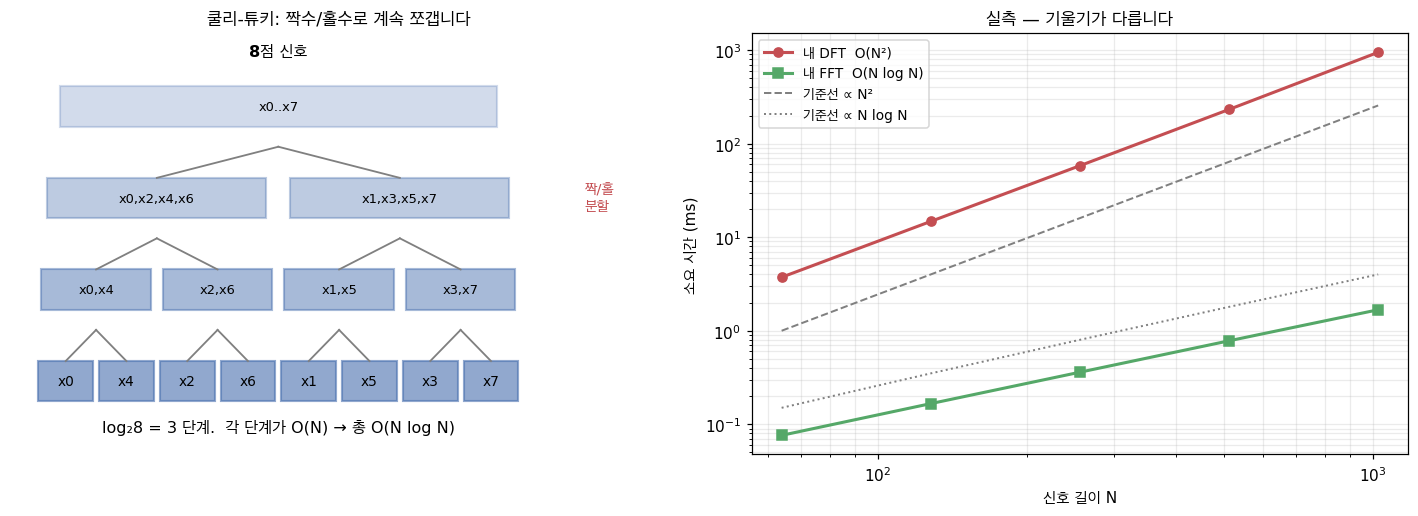

왼쪽: 8점 신호가 3단계 만에 낱개로 쪼개집니다. 이 단계 수가 log₂N 입니다.
오른쪽: 로그-로그 그래프에서 두 선의 '기울기'가 다릅니다.
        기울기 2 = O(N²), 기울기 ~1 = O(N log N). 이 차이가 전부입니다.


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

# (1) 8점 FFT의 분할 구조
ax1.axis("off")
levels = [["x0..x7"], ["x0,x2,x4,x6", "x1,x3,x5,x7"],
          ["x0,x4", "x2,x6", "x1,x5", "x3,x7"],
          ["x0", "x4", "x2", "x6", "x1", "x5", "x3", "x7"]]
for li, level in enumerate(levels):
    y = 3 - li
    for bi, label in enumerate(level):
        x = (bi + 0.5) / len(level)
        ax1.add_patch(plt.Rectangle((x - 0.45/len(level), y - 0.22), 0.9/len(level), 0.44,
                                    facecolor="#4c72b0", alpha=0.25 + li*0.12,
                                    edgecolor="#4c72b0", lw=1.4,
                                    transform=ax1.transData))
        ax1.text(x, y, label, ha="center", va="center", fontsize=8.5 if li < 3 else 9)
        if li > 0:
            parent_x = (bi // 2 + 0.5) / len(levels[li-1])
            ax1.plot([parent_x, x], [y + 0.22 + 0.34, y + 0.22], color="gray", lw=1.2)
ax1.text(0.5, 3.55, "8점 신호", ha="center", fontsize=10.5, weight="bold")
ax1.text(0.5, -0.55, "log₂8 = 3 단계.  각 단계가 O(N) → 총 O(N log N)",
         ha="center", fontsize=10.5)
ax1.text(1.13, 2, "짝/홀\n분할", fontsize=9.5, color="#c44e52", va="center")
ax1.set_xlim(-0.05, 1.3); ax1.set_ylim(-0.8, 3.8)
ax1.set_title("쿨리-튜키: 짝수/홀수로 계속 쪼갭니다", fontsize=11.5)

# (2) 실측 시간
ax2.loglog(sizes, [time_it(lambda s=list(rng.normal(size=n)): dft(s), repeats=1)*1000
                   for n in sizes], "o-", color="#c44e52", lw=2, label="내 DFT  O(N²)")
ax2.loglog(sizes, [time_it(lambda s=list(rng.normal(size=n)): fft(s))*1000
                   for n in sizes], "s-", color="#55a868", lw=2, label="내 FFT  O(N log N)")
ref_n = np.array(sizes, dtype=float)
ax2.loglog(ref_n, ref_n**2 / sizes[0]**2 * 1.0, "--", color="gray", lw=1.3, label="기준선 ∝ N²")
ax2.loglog(ref_n, ref_n*np.log2(ref_n) / (sizes[0]*math.log2(sizes[0])) * 0.15, ":",
           color="gray", lw=1.3, label="기준선 ∝ N log N")
ax2.set_xlabel("신호 길이 N"); ax2.set_ylabel("소요 시간 (ms)")
ax2.set_title("실측 — 기울기가 다릅니다", fontsize=11.5)
ax2.legend(fontsize=9); ax2.grid(alpha=0.25, which="both")

plt.tight_layout()
plt.show()

print("왼쪽: 8점 신호가 3단계 만에 낱개로 쪼개집니다. 이 단계 수가 log₂N 입니다.")
print("오른쪽: 로그-로그 그래프에서 두 선의 '기울기'가 다릅니다.")
print("        기울기 2 = O(N²), 기울기 ~1 = O(N log N). 이 차이가 전부입니다.")

## 4️⃣ 스펙트럼 읽기 · 주파수 해상도

### 📐 파워 스펙트럼과 위상 스펙트럼

$$P[k] = |X[k]|^2 = \operatorname{Re}(X[k])^2 + \operatorname{Im}(X[k])^2, \qquad
\phi[k] = \operatorname{atan2}(\operatorname{Im}X[k], \operatorname{Re}X[k])$$

- **파워 스펙트럼** — 각 주파수에 **에너지가 얼마나** 있나
- **위상 스펙트럼** — 각 주파수 성분이 **어디서 시작**하나

분석 작업 대부분은 **파워만 보고 위상은 무시**합니다.
다만 신호를 **복원**하려면 위상이 반드시 필요합니다. 아래에서 그 극적인 차이를 보여드리겠습니다.

### 📐 주파수 해상도 — 실무에서 가장 많이 헷갈리는 부분

표본 개수 `N`과 표본화율 `fs`가 주어졌을 때:

$$f_k = \frac{k \cdot f_s}{N}, \qquad \Delta f = \frac{f_s}{N}, \qquad f_{\max} = \frac{f_s}{2}$$

| 원하는 것 | 필요한 것 |
| --- | --- |
| **가까운 두 주파수 구분** | **표본 수 `N` 증가** (= 더 긴 관측 시간) |
| **더 높은 주파수 포착** | **표본화율 `fs` 증가** |

두 번째 줄이 8절(에일리어싱), 첫 번째 줄이 9절(제로 패딩)로 이어집니다.

> 💡 핵심: **해상도는 관측 시간 `T = N/fs` 에만 의존합니다.**
> `Δf = fs/N = 1/T` 이니까요. 1Hz 차이를 구분하려면 **최소 1초**를 관측해야 합니다.

In [7]:
def power_spectrum(X):
    return [abs(v) ** 2 for v in X]

fs = 128          # 표본화율 128 Hz
N = 128           # 1초 관측
t = np.arange(N) / fs
sig = 1.0 * np.sin(2*np.pi*10*t) + 0.5 * np.sin(2*np.pi*30*t + math.pi/3)

X = np.fft.rfft(sig)
freqs = np.fft.rfftfreq(N, d=1/fs)
P = np.abs(X) ** 2
phase = np.angle(X)

print(f"표본화율 fs = {fs} Hz,  표본 수 N = {N},  관측 시간 T = {N/fs:.2f}초")
print(f"  주파수 해상도 Δf = fs/N = {fs/N:.4f} Hz")
print(f"  최대 주파수(나이퀴스트) = fs/2 = {fs/2:.1f} Hz\n")

peaks = [i for i in range(1, len(P)-1) if P[i] > P[i-1] and P[i] > P[i+1] and P[i] > P.max()*0.01]
print(f"{'주파수(Hz)':>12}{'진폭':>12}{'위상(도)':>14}{'해석':>22}")
print("-" * 62)
for i in peaks:
    amp = 2 * abs(X[i]) / N
    print(f"{freqs[i]:>12.2f}{amp:>12.4f}{math.degrees(phase[i]):>14.2f}"
          f"{'원 신호와 일치':>22}")
print(f"\n  원 신호: 10Hz 진폭 1.0 (위상 -90°), 30Hz 진폭 0.5 (위상 {math.degrees(math.pi/3)-90:.0f}°)")
print("  (sin은 cos보다 90° 뒤처지므로 위상이 -90° 만큼 이동해 보입니다)")

print("\n[위상을 버리면 어떻게 되나]")
mag_only = np.abs(X)                            # 위상을 전부 0으로
recon_nophase = np.fft.irfft(mag_only, n=N)
recon_full = np.fft.irfft(X, n=N)
print(f"  위상 포함 복원 오차 : {np.abs(recon_full - sig).max():.2e}   <- 완벽")
print(f"  위상 버린 복원 오차 : {np.abs(recon_nophase - sig).max():.4f}   <- 완전히 다른 신호")
print("  => 파워 스펙트럼만으로는 신호를 되살릴 수 없습니다. 위상에도 정보가 있습니다.")

표본화율 fs = 128 Hz,  표본 수 N = 128,  관측 시간 T = 1.00초
  주파수 해상도 Δf = fs/N = 1.0000 Hz
  최대 주파수(나이퀴스트) = fs/2 = 64.0 Hz

     주파수(Hz)          진폭         위상(도)                    해석
--------------------------------------------------------------
       10.00      1.0000        -90.00              원 신호와 일치
       30.00      0.5000        -30.00              원 신호와 일치

  원 신호: 10Hz 진폭 1.0 (위상 -90°), 30Hz 진폭 0.5 (위상 -30°)
  (sin은 cos보다 90° 뒤처지므로 위상이 -90° 만큼 이동해 보입니다)

[위상을 버리면 어떻게 되나]
  위상 포함 복원 오차 : 4.44e-16   <- 완벽
  위상 버린 복원 오차 : 1.6192   <- 완전히 다른 신호
  => 파워 스펙트럼만으로는 신호를 되살릴 수 없습니다. 위상에도 정보가 있습니다.


### 🖼️ 그림 2 — 진폭만으로는 부족합니다

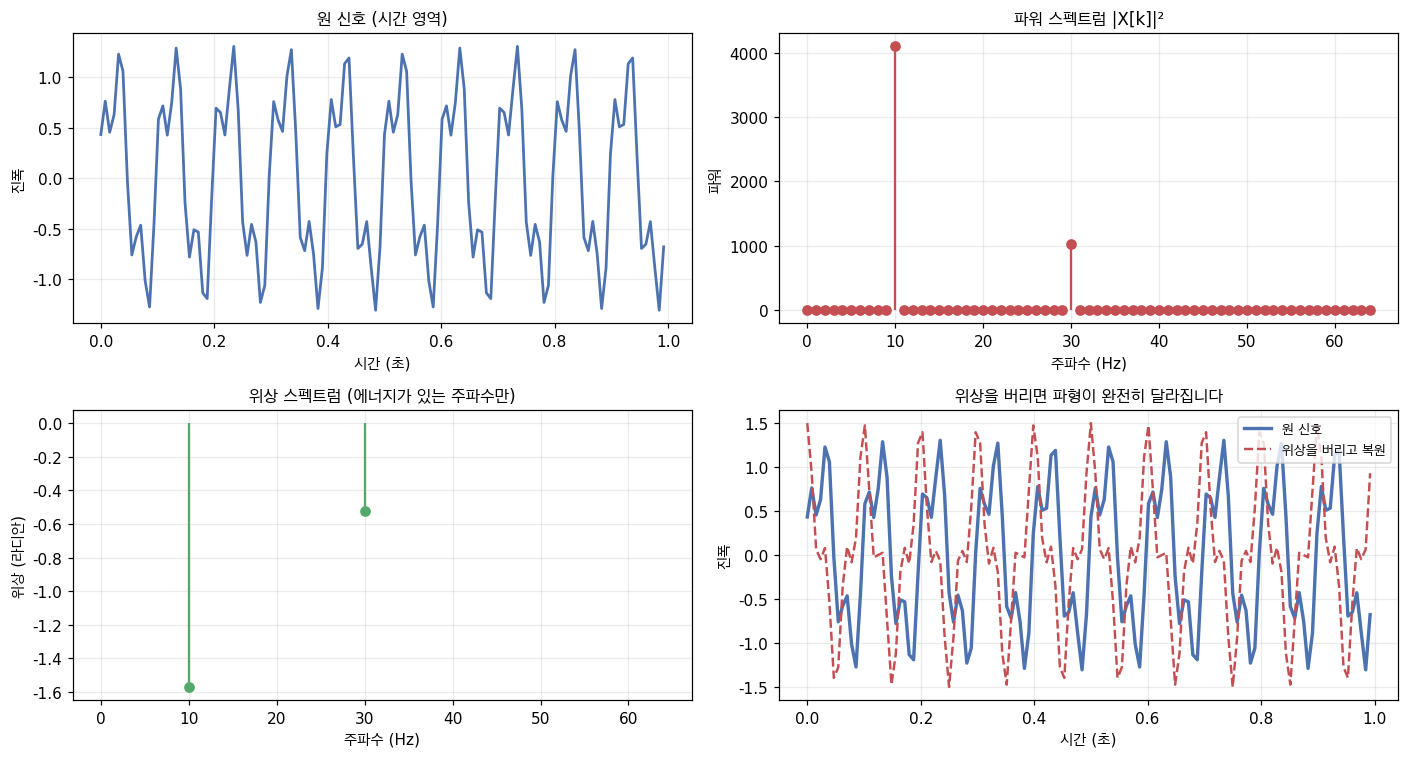

오른쪽 아래를 보세요. 진폭 스펙트럼이 완전히 같은데도 파형이 전혀 다릅니다.
'파워 스펙트럼만 보면 된다'는 건 분석할 때 이야기이고, 복원에는 위상이 필수입니다.


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

axes[0][0].plot(t, sig, lw=1.8, color="#4c72b0")
axes[0][0].set_title("원 신호 (시간 영역)", fontsize=11)
axes[0][0].set_xlabel("시간 (초)"); axes[0][0].set_ylabel("진폭")
axes[0][0].grid(alpha=0.25)

axes[0][1].stem(freqs, P, basefmt=" ", linefmt="#c44e52", markerfmt="o")
axes[0][1].set_title("파워 스펙트럼 |X[k]|²", fontsize=11)
axes[0][1].set_xlabel("주파수 (Hz)"); axes[0][1].set_ylabel("파워")
axes[0][1].grid(alpha=0.25)

sig_phase = np.where(P > P.max() * 0.01, phase, np.nan)
axes[1][0].stem(freqs, sig_phase, basefmt=" ", linefmt="#55a868", markerfmt="o")
axes[1][0].set_title("위상 스펙트럼 (에너지가 있는 주파수만)", fontsize=11)
axes[1][0].set_xlabel("주파수 (Hz)"); axes[1][0].set_ylabel("위상 (라디안)")
axes[1][0].grid(alpha=0.25)

axes[1][1].plot(t, sig, lw=2.2, color="#4c72b0", label="원 신호")
axes[1][1].plot(t, recon_nophase, lw=1.6, color="#c44e52", ls="--",
                label="위상을 버리고 복원")
axes[1][1].set_title("위상을 버리면 파형이 완전히 달라집니다", fontsize=11)
axes[1][1].set_xlabel("시간 (초)"); axes[1][1].set_ylabel("진폭")
axes[1][1].legend(fontsize=9); axes[1][1].grid(alpha=0.25)

plt.tight_layout()
plt.show()
print("오른쪽 아래를 보세요. 진폭 스펙트럼이 완전히 같은데도 파형이 전혀 다릅니다.")
print("'파워 스펙트럼만 보면 된다'는 건 분석할 때 이야기이고, 복원에는 위상이 필수입니다.")

## 5️⃣ 🔑 합성곱 정리 — CNN과 직결됩니다

신호처리에서 가장 중요한 결과이고, CNN과 직접 연결됩니다.

> ### **시간 영역의 합성곱 = 주파수 영역의 원소별 곱셈**

$$x * h = \text{IFFT}\big(\text{FFT}(x) \cdot \text{FFT}(h)\big)$$

### 🔑 왜 중요한가 — 비용이 바뀝니다

| 방법 | 비용 |
| --- | --- |
| 직접 합성곱 (길이 `N`과 `M`) | **O(N·M)** |
| FFT 합성곱 | **O(N log N)** — 변환, 곱, 역변환 |

**커널이 클수록 FFT 방식이 압도적으로 유리**합니다.
수용 영역(receptive field)이 큰 합성곱 층에서 실제로 벌어지는 일이에요.

### ⚠️ 주의: DFT는 '원형 합성곱'을 계산합니다

DFT는 신호가 **주기적이라고 가정**합니다. 그래서 끝에서 처음으로 **되감기(wrap around)** 가 일어나요.

**선형 합성곱**(되감기 없는 보통의 합성곱)을 원하면,
두 신호를 **길이 `N + M − 1`까지 0으로 채운 뒤** 변환해야 합니다.

이 차이를 모르면 결과가 미묘하게 틀리는데, 원인을 찾기가 아주 어렵습니다.
아래에서 두 경우를 나란히 보여드리겠습니다.

In [9]:
def circular_convolve_direct(x, h):
    N = len(x)
    return [sum(x[m] * h[(n - m) % N] for m in range(N)) for n in range(N)]

def linear_convolve_direct(x, h):
    N, M = len(x), len(h)
    out = [0.0] * (N + M - 1)
    for n in range(N):
        for m in range(M):
            out[n + m] += x[n] * h[m]
    return out

def convolve_fft(x, h, circular=False):
    if circular:
        size = len(x)
        xp, hp = list(x), list(h)
    else:
        size = 1
        need = len(x) + len(h) - 1
        while size < need:
            size *= 2                                # FFT를 위해 2의 거듭제곱으로
        xp = list(x) + [0.0] * (size - len(x))
        hp = list(h) + [0.0] * (size - len(h))
    X, H = fft(xp), fft(hp)
    Y = [a * b for a, b in zip(X, H)]
    y = idft(Y)
    n_out = len(x) if circular else len(x) + len(h) - 1
    return [v.real for v in y[:n_out]]

x = [1.0, 2.0, 3.0, 4.0, 0.0, 0.0, 0.0, 0.0]
h = [1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]

print("연습 3 — 합성곱 정리 검증\n")
print(f"  x = {x}")
print(f"  h = {h}\n")

circ_direct = circular_convolve_direct(x, h)
circ_fft = convolve_fft(x, h, circular=True)
print("[원형 합성곱 — DFT가 자연스럽게 계산하는 것]")
print(f"  직접 계산 : {[round(v, 6) for v in circ_direct]}")
print(f"  FFT 방식  : {[round(v, 6) for v in circ_fft]}")
print(f"  최대 차이 : {max(abs(a-b) for a, b in zip(circ_direct, circ_fft)):.2e} ✓")

xs, hs = [1.0, 2.0, 3.0, 4.0], [1.0, 1.0, 1.0]
lin_direct = linear_convolve_direct(xs, hs)
lin_fft = convolve_fft(xs, hs, circular=False)
print(f"\n[선형 합성곱 — 제로 패딩이 필요합니다]")
print(f"  x = {xs},  h = {hs}   (출력 길이 = {len(xs)}+{len(hs)}-1 = {len(lin_direct)})")
print(f"  직접 계산    : {[round(v, 6) for v in lin_direct]}")
print(f"  FFT 방식     : {[round(v, 6) for v in lin_fft]}")
print(f"  np.convolve  : {np.convolve(xs, hs)}")
print(f"  최대 차이    : {max(abs(a-b) for a, b in zip(lin_direct, lin_fft)):.2e} ✓")

print(f"\n[⚠️ 패딩을 안 하면 어떻게 되나 — 되감기의 정체]")
short_circ = circular_convolve_direct(xs, hs + [0.0])
print(f"  패딩 없이 원형 합성곱 : {[round(v,4) for v in short_circ]}")
print(f"  올바른 선형 합성곱    : {[round(v,4) for v in lin_direct]}")
print("  => 앞부분이 다릅니다. 끝에서 넘친 값이 앞으로 되감겨 더해졌기 때문입니다.")

연습 3 — 합성곱 정리 검증

  x = [1.0, 2.0, 3.0, 4.0, 0.0, 0.0, 0.0, 0.0]
  h = [1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]

[원형 합성곱 — DFT가 자연스럽게 계산하는 것]
  직접 계산 : [1.0, 3.0, 6.0, 9.0, 7.0, 4.0, 0.0, 0.0]
  FFT 방식  : [1.0, 3.0, 6.0, 9.0, 7.0, 4.0, 0.0, 0.0]
  최대 차이 : 4.44e-15 ✓

[선형 합성곱 — 제로 패딩이 필요합니다]
  x = [1.0, 2.0, 3.0, 4.0],  h = [1.0, 1.0, 1.0]   (출력 길이 = 4+3-1 = 6)
  직접 계산    : [1.0, 3.0, 6.0, 9.0, 7.0, 4.0]
  FFT 방식     : [1.0, 3.0, 6.0, 9.0, 7.0, 4.0]
  np.convolve  : [1. 3. 6. 9. 7. 4.]
  최대 차이    : 4.44e-15 ✓

[⚠️ 패딩을 안 하면 어떻게 되나 — 되감기의 정체]
  패딩 없이 원형 합성곱 : [8.0, 7.0, 6.0, 9.0]
  올바른 선형 합성곱    : [1.0, 3.0, 6.0, 9.0, 7.0, 4.0]
  => 앞부분이 다릅니다. 끝에서 넘친 값이 앞으로 되감겨 더해졌기 때문입니다.


In [10]:
# 🏭 커널이 커질수록 FFT가 유리해지는 지점 찾기
print("직접 합성곱 vs FFT 합성곱 — 언제 역전되나\n")
print(f"{'신호 길이':>12}{'커널 길이':>12}{'직접 (ms)':>14}{'FFT (ms)':>14}{'승자':>12}")
print("-" * 66)
rng = np.random.default_rng(5)
for n_sig, n_ker in [(512, 3), (512, 15), (512, 63), (512, 255), (2048, 255)]:
    xx = rng.normal(size=n_sig)
    hh = rng.normal(size=n_ker)
    t_direct = time_it(lambda: np.convolve(xx, hh), repeats=3)
    from scipy.signal import fftconvolve
    t_fft = time_it(lambda: fftconvolve(xx, hh), repeats=3)
    winner = "직접" if t_direct < t_fft else "FFT"
    print(f"{n_sig:>12}{n_ker:>12}{t_direct*1000:>14.4f}{t_fft*1000:>14.4f}{winner:>12}")

print("\n=> 커널이 작으면(3, 15) 직접 합성곱이 빠릅니다. 오버헤드가 없으니까요.")
print("   커널이 커지면 FFT가 이깁니다. O(N·M) vs O(N log N)의 차이가 드러나는 거죠.")
print("\n   🏭 그래서 CNN의 3×3 커널은 직접 합성곱을 씁니다 (cuDNN도 그렇습니다).")
print("      큰 커널이나 전역 합성곱에서는 FFT 기반이 훨씬 빠르고,")
print("      FNet 같은 구조는 아예 어텐션을 FFT로 대체해 O(N²)를 O(N log N)으로 만듭니다.")

직접 합성곱 vs FFT 합성곱 — 언제 역전되나

       신호 길이       커널 길이       직접 (ms)      FFT (ms)          승자
------------------------------------------------------------------
         512           3        0.0017        0.0390          직접
         512          15        0.0050        0.0316          직접
         512          63        0.0115        0.0297          직접
         512         255        0.0496        0.0301         FFT
        2048         255        0.1625        0.0427         FFT

=> 커널이 작으면(3, 15) 직접 합성곱이 빠릅니다. 오버헤드가 없으니까요.
   커널이 커지면 FFT가 이깁니다. O(N·M) vs O(N log N)의 차이가 드러나는 거죠.

   🏭 그래서 CNN의 3×3 커널은 직접 합성곱을 씁니다 (cuDNN도 그렇습니다).
      큰 커널이나 전역 합성곱에서는 FFT 기반이 훨씬 빠르고,
      FNet 같은 구조는 아예 어텐션을 FFT로 대체해 O(N²)를 O(N log N)으로 만듭니다.


### 🖼️ 그림 3 — 합성곱 정리를 눈으로

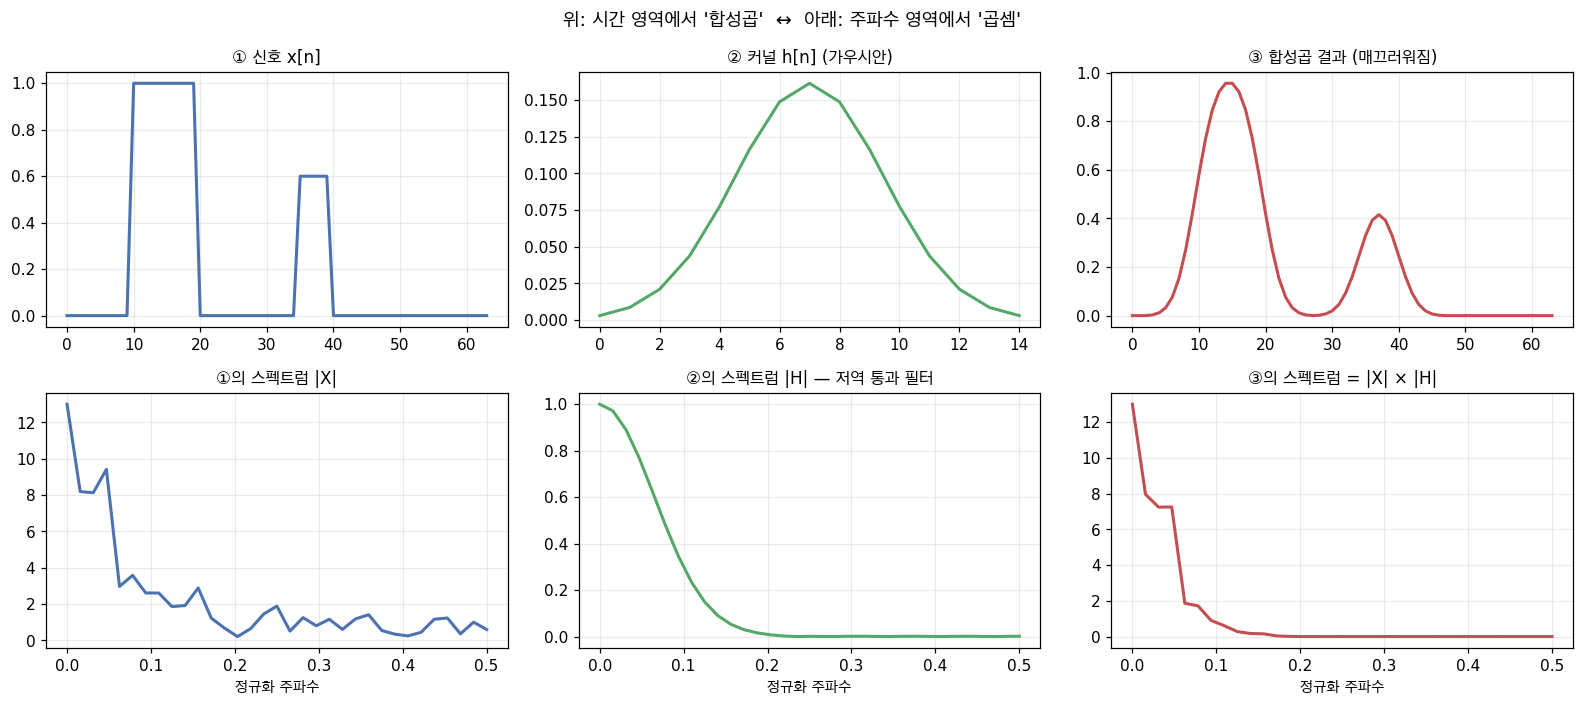

아래 오른쪽 = 아래 왼쪽 × 아래 가운데 (원소별 곱)입니다.
가우시안 커널의 스펙트럼이 고주파에서 0에 가깝습니다 = 저역 통과 필터입니다.
그래서 곱하면 신호의 고주파가 깎이고, 시간 영역에서는 '매끄러워지는' 것으로 나타납니다.

💡 '블러 = 저역 통과' 라는 직관이 여기서 수식으로 확인됩니다.


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14.5, 6.5))

xs_sig = np.zeros(64)
xs_sig[10:20] = 1.0                              # 사각 펄스
xs_sig[35:40] = 0.6
kernel = np.exp(-np.linspace(-2, 2, 15)**2)      # 가우시안 커널
kernel /= kernel.sum()

conv_direct = np.convolve(xs_sig, kernel, mode="same")

Xf = np.fft.rfft(xs_sig)
Hf = np.fft.rfft(kernel, n=len(xs_sig))
Yf = Xf * Hf

axes[0][0].plot(xs_sig, lw=2, color="#4c72b0")
axes[0][0].set_title("① 신호 x[n]", fontsize=11); axes[0][0].grid(alpha=0.25)
axes[0][1].plot(kernel, lw=2, color="#55a868")
axes[0][1].set_title("② 커널 h[n] (가우시안)", fontsize=11); axes[0][1].grid(alpha=0.25)
axes[0][2].plot(conv_direct, lw=2, color="#c44e52")
axes[0][2].set_title("③ 합성곱 결과 (매끄러워짐)", fontsize=11); axes[0][2].grid(alpha=0.25)

fr = np.fft.rfftfreq(len(xs_sig))
axes[1][0].plot(fr, np.abs(Xf), lw=2, color="#4c72b0")
axes[1][0].set_title("①의 스펙트럼 |X|", fontsize=11)
axes[1][0].set_xlabel("정규화 주파수"); axes[1][0].grid(alpha=0.25)
axes[1][1].plot(fr, np.abs(Hf), lw=2, color="#55a868")
axes[1][1].set_title("②의 스펙트럼 |H| — 저역 통과 필터", fontsize=11)
axes[1][1].set_xlabel("정규화 주파수"); axes[1][1].grid(alpha=0.25)
axes[1][2].plot(fr, np.abs(Yf), lw=2, color="#c44e52")
axes[1][2].set_title("③의 스펙트럼 = |X| × |H|", fontsize=11)
axes[1][2].set_xlabel("정규화 주파수"); axes[1][2].grid(alpha=0.25)

plt.suptitle("위: 시간 영역에서 '합성곱'  ↔  아래: 주파수 영역에서 '곱셈'", fontsize=12.5)
plt.tight_layout()
plt.show()

print("아래 오른쪽 = 아래 왼쪽 × 아래 가운데 (원소별 곱)입니다.")
print("가우시안 커널의 스펙트럼이 고주파에서 0에 가깝습니다 = 저역 통과 필터입니다.")
print("그래서 곱하면 신호의 고주파가 깎이고, 시간 영역에서는 '매끄러워지는' 것으로 나타납니다.")
print("\n💡 '블러 = 저역 통과' 라는 직관이 여기서 수식으로 확인됩니다.")

## 6️⃣ 스펙트럼 누설과 윈도우 함수

### ⚠️ DFT의 숨은 가정

**DFT는 신호가 주기적이라고 가정합니다.** `N`개 표본을 **무한 반복되는 신호의 한 주기**로 봅니다.

그래서 신호의 시작값과 끝값이 다르면, 이어붙인 지점에 **불연속(뚝 끊김)** 이 생깁니다.
그리고 급격한 불연속은 **모든 주파수에 에너지를 퍼뜨립니다.**

이걸 **스펙트럼 누설(spectral leakage)** 이라고 합니다.
실제로는 없는 주파수 성분이 스펙트럼에 나타나는 거예요.

### 📐 윈도우 함수 — 양끝을 0으로 부드럽게 깎기

$$w_{\text{Hann}}[n] = 0.5\left(1 - \cos\frac{2\pi n}{N-1}\right), \qquad
w_{\text{Hamming}}[n] = 0.54 - 0.46\cos\frac{2\pi n}{N-1}$$

DFT 전에 신호에 **원소별로 곱합니다**: `X = DFT(x · w)`

| 윈도우 | 주엽 폭 | 부엽 크기 | 쓰는 곳 |
| --- | --- | --- | --- |
| 사각형 (윈도우 없음) | **가장 좁음** | 가장 큼 (−13 dB) | 신호가 정확히 주기적일 때 |
| **Hann** | 보통 | 작음 (−31 dB) | **범용 스펙트럼 분석** |
| Hamming | 보통 | 더 작음 (−42 dB) | 오디오·음성 |
| Blackman | 넓음 | 아주 작음 (−58 dB) | 부엽 억제가 중요할 때 |

### 🔑 트레이드오프가 있습니다

윈도우를 쓰면 **누설은 줄지만 주엽이 넓어집니다.**
즉 **가짜 봉우리는 사라지는데, 진짜 봉우리 두 개를 구분하는 능력은 떨어집니다.**
공짜가 아니에요. 아래에서 두 효과를 모두 보여드리겠습니다.

In [12]:
def hann(N):
    return np.array([0.5 * (1 - math.cos(2*math.pi*n/(N-1))) for n in range(N)])

def hamming(N):
    return np.array([0.54 - 0.46*math.cos(2*math.pi*n/(N-1)) for n in range(N)])

def blackman(N):
    return np.array([0.42 - 0.5*math.cos(2*math.pi*n/(N-1))
                     + 0.08*math.cos(4*math.pi*n/(N-1)) for n in range(N)])

# 상황 A: 주파수가 빈에 딱 안 맞을 때 -> 누설이 생깁니다
fs, N = 128, 128
t = np.arange(N) / fs
sig_fit = np.sin(2*np.pi*10*t)        # 10 Hz — 빈에 정확히 맞음
sig_leak = np.sin(2*np.pi*10.5*t)     # 10.5 Hz — 빈 사이에 걸침

print("스펙트럼 누설: 주파수가 '빈'에 딱 맞느냐가 결정합니다\n")
print(f"주파수 해상도 Δf = {fs/N} Hz  ->  빈은 0, 1, 2, ... Hz 에 있습니다\n")
for name, s in [("10.0 Hz (빈에 정확히 일치)", sig_fit), ("10.5 Hz (빈 사이에 걸침)", sig_leak)]:
    P = np.abs(np.fft.rfft(s)) ** 2
    P = P / P.max()
    spread = int(np.sum(P > 0.01))
    print(f"  {name}")
    print(f"    파워가 1% 넘는 빈의 개수: {spread}개")
    print(f"    최대 봉우리 밖의 에너지 비율: {(P.sum() - P.max())/P.sum()*100:.2f}%")

print("\n[윈도우를 적용하면 누설이 줄어듭니다]  (10.5 Hz 신호)")
print("  '먼 곳 누설' = 봉우리에서 5빈 이상 떨어진 곳으로 새어 나간 에너지 비율")
print("  '최대 부엽'  = 봉우리 대비 가장 큰 곁봉우리의 크기 (dB, 낮을수록 좋음)\n")
print(f"{'윈도우':<14}{'먼 곳 누설':>16}{'최대 부엽':>16}")
print("-" * 48)
for name, w in [("사각형(없음)", np.ones(N)), ("Hann", hann(N)),
                ("Hamming", hamming(N)), ("Blackman", blackman(N))]:
    P = np.abs(np.fft.rfft(sig_leak * w)) ** 2
    P = P / P.sum()
    pk = int(np.argmax(P))
    far = sum(P[i] for i in range(len(P)) if abs(i - pk) > 5)
    side = max(P[i] for i in range(len(P)) if abs(i - pk) > 3)
    print(f"{name:<14}{far*100:>15.4f}%{10*math.log10(side/P.max()):>13.1f} dB")

print("\n=> 사각형은 먼 곳 누설이 3% 가까이 되는데, 윈도우를 쓰면 0.001% 수준으로 떨어집니다.")
print("   Blackman이 부엽 억제에서 가장 강합니다 (약 -57 dB).")
print("   다만 아래 연습 4에서 보듯, 대가로 '가까운 두 주파수를 구분하는 능력'을 잃습니다.")

스펙트럼 누설: 주파수가 '빈'에 딱 맞느냐가 결정합니다

주파수 해상도 Δf = 1.0 Hz  ->  빈은 0, 1, 2, ... Hz 에 있습니다

  10.0 Hz (빈에 정확히 일치)
    파워가 1% 넘는 빈의 개수: 1개
    최대 봉우리 밖의 에너지 비율: 0.00%
  10.5 Hz (빈 사이에 걸침)
    파워가 1% 넘는 빈의 개수: 11개
    최대 봉우리 밖의 에너지 비율: 57.72%

[윈도우를 적용하면 누설이 줄어듭니다]  (10.5 Hz 신호)
  '먼 곳 누설' = 봉우리에서 5빈 이상 떨어진 곳으로 새어 나간 에너지 비율
  '최대 부엽'  = 봉우리 대비 가장 큰 곁봉우리의 크기 (dB, 낮을수록 좋음)

윈도우                     먼 곳 누설           최대 부엽
------------------------------------------------
사각형(없음)                2.9434%        -17.3 dB
Hann                   0.0007%        -40.2 dB
Hamming                0.0399%        -38.3 dB
Blackman               0.0001%        -57.2 dB

=> 사각형은 먼 곳 누설이 3% 가까이 되는데, 윈도우를 쓰면 0.001% 수준으로 떨어집니다.
   Blackman이 부엽 억제에서 가장 강합니다 (약 -57 dB).
   다만 아래 연습 4에서 보듯, 대가로 '가까운 두 주파수를 구분하는 능력'을 잃습니다.


### 🖼️ 그림 4 — 누설과 윈도우의 트레이드오프

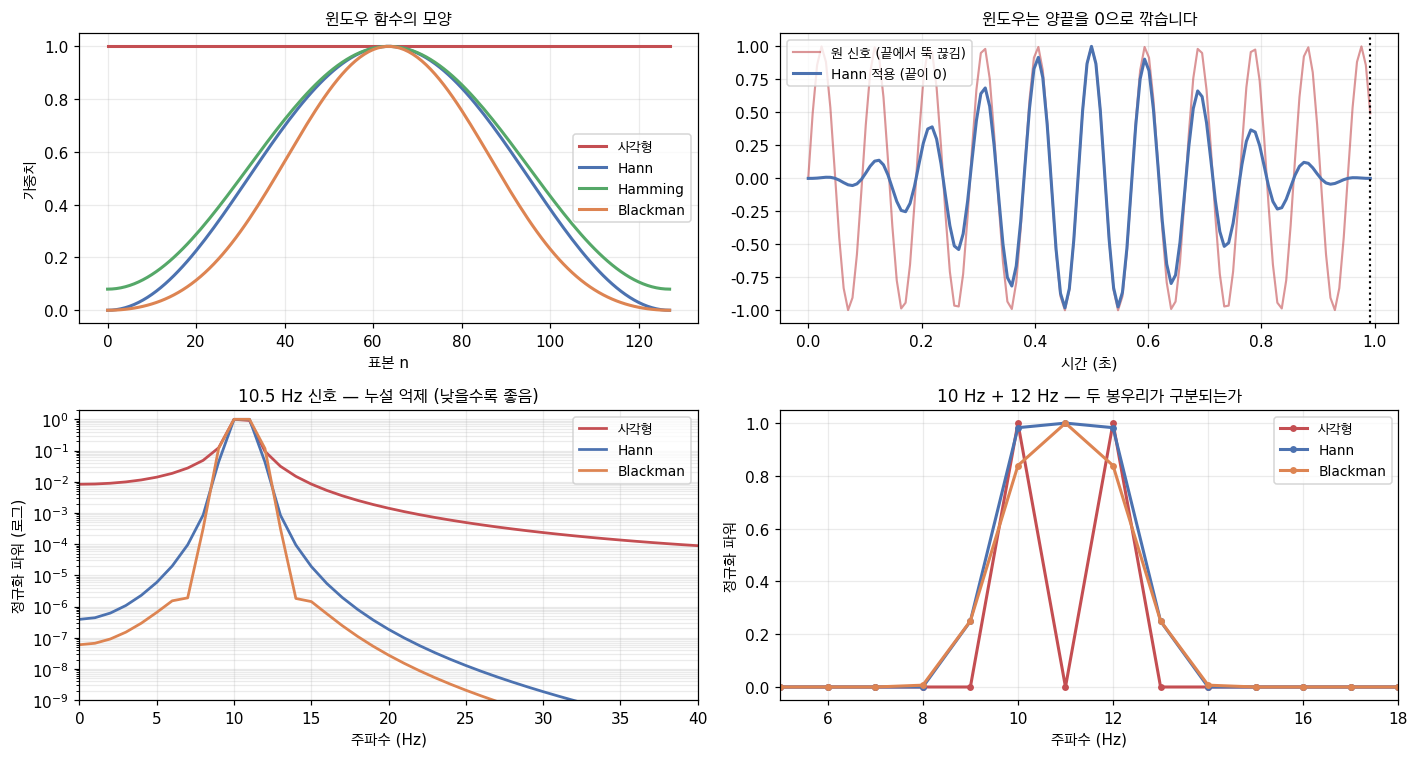

왼쪽 아래: Blackman이 누설을 가장 잘 억제합니다 (선이 가장 아래).
오른쪽 아래: 그런데 같은 Blackman이 두 봉우리를 뭉개 버립니다.

=> 이게 트레이드오프입니다. 부엽을 낮추면 주엽이 넓어집니다.
   '가짜 주파수를 없앨 것인가' vs '진짜 주파수를 구분할 것인가' 중에 골라야 합니다.


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# (1) 윈도우 모양
n = np.arange(N)
for name, w, c in [("사각형", np.ones(N), "#c44e52"), ("Hann", hann(N), "#4c72b0"),
                   ("Hamming", hamming(N), "#55a868"), ("Blackman", blackman(N), "#dd8452")]:
    axes[0][0].plot(n, w, lw=2, label=name, color=c)
axes[0][0].set_title("윈도우 함수의 모양", fontsize=11)
axes[0][0].set_xlabel("표본 n"); axes[0][0].set_ylabel("가중치")
axes[0][0].legend(fontsize=9); axes[0][0].grid(alpha=0.25)

# (2) 신호에 적용한 모습
axes[0][1].plot(t, sig_leak, lw=1.4, color="#c44e52", alpha=0.6, label="원 신호 (끝에서 뚝 끊김)")
axes[0][1].plot(t, sig_leak * hann(N), lw=2, color="#4c72b0", label="Hann 적용 (끝이 0)")
axes[0][1].axvline(t[-1], color="black", ls=":", lw=1.4)
axes[0][1].set_title("윈도우는 양끝을 0으로 깎습니다", fontsize=11)
axes[0][1].set_xlabel("시간 (초)"); axes[0][1].legend(fontsize=9); axes[0][1].grid(alpha=0.25)

# (3) 누설 비교 (10.5 Hz)
fr = np.fft.rfftfreq(N, d=1/fs)
for name, w, c in [("사각형", np.ones(N), "#c44e52"), ("Hann", hann(N), "#4c72b0"),
                   ("Blackman", blackman(N), "#dd8452")]:
    P = np.abs(np.fft.rfft(sig_leak * w)) ** 2
    axes[1][0].semilogy(fr, P / P.max(), lw=1.8, label=name, color=c)
axes[1][0].set_xlim(0, 40); axes[1][0].set_ylim(1e-9, 2)
axes[1][0].set_title("10.5 Hz 신호 — 누설 억제 (낮을수록 좋음)", fontsize=11)
axes[1][0].set_xlabel("주파수 (Hz)"); axes[1][0].set_ylabel("정규화 파워 (로그)")
axes[1][0].legend(fontsize=9); axes[1][0].grid(alpha=0.25, which="both")

# (4) 해상도 손실 (연습 4: 10 Hz와 12 Hz)
sig_two = np.sin(2*np.pi*10*t) + np.sin(2*np.pi*12*t)
for name, w, c in [("사각형", np.ones(N), "#c44e52"), ("Hann", hann(N), "#4c72b0"),
                   ("Blackman", blackman(N), "#dd8452")]:
    P = np.abs(np.fft.rfft(sig_two * w)) ** 2
    axes[1][1].plot(fr, P / P.max(), lw=2, label=name, color=c, marker="o", ms=3.5)
axes[1][1].set_xlim(5, 18)
axes[1][1].set_title("10 Hz + 12 Hz — 두 봉우리가 구분되는가", fontsize=11)
axes[1][1].set_xlabel("주파수 (Hz)"); axes[1][1].set_ylabel("정규화 파워")
axes[1][1].legend(fontsize=9); axes[1][1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("왼쪽 아래: Blackman이 누설을 가장 잘 억제합니다 (선이 가장 아래).")
print("오른쪽 아래: 그런데 같은 Blackman이 두 봉우리를 뭉개 버립니다.")
print("\n=> 이게 트레이드오프입니다. 부엽을 낮추면 주엽이 넓어집니다.")
print("   '가짜 주파수를 없앨 것인가' vs '진짜 주파수를 구분할 것인가' 중에 골라야 합니다.")

## 7️⃣ DFT의 성질들

| 성질 | 시간 영역 | 주파수 영역 |
| --- | --- | --- |
| **선형성** | `a·x + b·y` | `a·X + b·Y` |
| **시간 이동** | `x[n−k]` | `X[f]·e^(−2πifk/N)` — **크기는 그대로, 위상만 바뀜** |
| **주파수 이동** | `x[n]·e^(2πif₀n/N)` | `X[f−f₀]` |
| **합성곱** | `x * h` | `X·H` (원소별) |
| **곱셈** | `x·h` (원소별) | `X * H` (원형 합성곱 / N) |
| **파스발 정리** | `Σ|x[n]|²` | `(1/N)·Σ|X[k]|²` |
| **켤레 대칭** (실수 입력) | `x[n]` 실수 | `X[k] = conj(X[N−k])` |

### 🔑 두 가지를 강조하고 싶습니다

**시간 이동 → 위상만 변합니다.**
신호를 옆으로 밀어도 **파워 스펙트럼은 완전히 동일**합니다.
이래서 파워 스펙트럼이 **이동 불변(shift-invariant)** 특징이 됩니다.
오디오 분류에서 "소리가 언제 났는지"와 무관하게 "무슨 소리인지"를 잡아내는 근거죠.

**파스발 정리 → 에너지가 보존됩니다.**
변환을 해도 총 에너지가 같습니다. **DFT는 회전(직교 변환)** 이니까요.
2절에서 본 직교성의 또 다른 표현입니다.

In [14]:
rng = np.random.default_rng(3)
N = 64
x = rng.normal(size=N)
y = rng.normal(size=N)
X, Y = np.fft.fft(x), np.fft.fft(y)

print("[선형성]  DFT(a·x + b·y) = a·X + b·Y")
a, b = 2.5, -1.3
lhs = np.fft.fft(a*x + b*y)
print(f"  최대 차이: {np.abs(lhs - (a*X + b*Y)).max():.2e} ✓")

print("\n[시간 이동]  신호를 밀면 크기는 그대로, 위상만 바뀝니다")
shift = 7
x_shift = np.roll(x, shift)
X_shift = np.fft.fft(x_shift)
print(f"  {shift}칸 이동 후 |X| 의 최대 변화: {np.abs(np.abs(X_shift) - np.abs(X)).max():.2e}")
print(f"  위상 변화가 예측대로인가: "
      f"{np.abs(X_shift - X * np.exp(-2j*np.pi*np.arange(N)*shift/N)).max():.2e} ✓")
print("  => 파워 스펙트럼은 '언제 일어났는지'에 무관합니다 = 이동 불변 특징")

print("\n[파스발 정리]  에너지 보존")
e_time = np.sum(np.abs(x) ** 2)
e_freq = np.sum(np.abs(X) ** 2) / N
print(f"  시간 영역 Σ|x[n]|²      = {e_time:.10f}")
print(f"  주파수 영역 (1/N)Σ|X|²  = {e_freq:.10f}")
print(f"  차이: {abs(e_time - e_freq):.2e} ✓")
print("  => DFT는 에너지를 보존하는 '회전'입니다.")

print("\n[곱셈 ↔ 합성곱의 쌍대성]")
prod_time = x * y                                    # 시간 영역 원소별 곱
lhs2 = np.fft.fft(prod_time)
rhs2 = np.array([sum(X[m] * Y[(k - m) % N] for m in range(N)) for k in range(N)]) / N
print(f"  DFT(x·y) vs (X*Y)/N 의 최대 차이: {np.abs(lhs2 - rhs2).max():.2e} ✓")
print("  => 한쪽에서 곱하면 다른 쪽에서 합성곱. 5절의 정확한 반대 방향입니다.")

[선형성]  DFT(a·x + b·y) = a·X + b·Y
  최대 차이: 1.07e-14 ✓

[시간 이동]  신호를 밀면 크기는 그대로, 위상만 바뀝니다
  7칸 이동 후 |X| 의 최대 변화: 3.55e-15
  위상 변화가 예측대로인가: 5.84e-14 ✓
  => 파워 스펙트럼은 '언제 일어났는지'에 무관합니다 = 이동 불변 특징

[파스발 정리]  에너지 보존
  시간 영역 Σ|x[n]|²      = 73.0796314410
  주파수 영역 (1/N)Σ|X|²  = 73.0796314410
  차이: 0.00e+00 ✓
  => DFT는 에너지를 보존하는 '회전'입니다.

[곱셈 ↔ 합성곱의 쌍대성]
  DFT(x·y) vs (X*Y)/N 의 최대 차이: 7.16e-15 ✓
  => 한쪽에서 곱하면 다른 쪽에서 합성곱. 5절의 정확한 반대 방향입니다.


## 8️⃣ 에일리어싱 — 표본화가 만드는 착시

신호에 `fs/2`(**나이퀴스트 주파수**)보다 높은 주파수가 있으면,
`fs`로 표본화할 때 **가짜 저주파로 둔갑**합니다.

```
진짜 신호  : 90 Hz 사인파
표본화율   : 100 Hz
보이는 것  : 100 - 90 = 10 Hz

90 Hz 신호를 100 Hz로 표본화한 값들은
10 Hz 신호를 표본화한 값들과 '완전히 동일'합니다.
어떤 수학을 동원해도 원래 90 Hz를 복원할 수 없습니다.
```

정보가 **애초에 기록되지 않은 것**이라 복구가 불가능합니다.

### 🏭 그래서 실무에서는

- **아날로그-디지털 변환기**에 **안티에일리어싱 필터**가 들어갑니다.
  표본화 **전에** 나이퀴스트 위 주파수를 잘라내는 거죠.
- **ML에서도 나타납니다.** 특징 맵을 다운샘플링할 때 저역 통과 필터 없이 하면
  똑같은 문제가 생깁니다. 그래서 **안티에일리어싱 풀링 층**을 쓰는 구조들이 있습니다.

바퀴가 거꾸로 도는 것처럼 보이는 영화 장면(왜건 휠 효과)도 정확히 이 현상입니다.

In [15]:
fs_sample = 100.0
print(f"표본화율 {fs_sample:.0f} Hz, 나이퀴스트 = {fs_sample/2:.0f} Hz\n")
print(f"{'진짜 주파수':>14}{'관측되는 주파수':>18}{'에일리어싱?':>16}")
print("-" * 50)
for f_true in [10, 30, 49, 51, 70, 90, 110, 190]:
    # 관측 주파수 = |f - round(f/fs)*fs|
    f_obs = abs(f_true - round(f_true / fs_sample) * fs_sample)
    alias = "❌ 발생!" if f_true > fs_sample/2 else "정상"
    print(f"{f_true:>12} Hz{f_obs:>16.0f} Hz{alias:>16}")

print("\n[표본값이 정말 같은지 확인]")
n = np.arange(20)
s90 = np.sin(2*np.pi*90*n/fs_sample)
s10 = np.sin(2*np.pi*10*n/fs_sample)
print(f"  90 Hz 표본: {np.round(s90[:8], 4)}")
print(f"  10 Hz 표본: {np.round(s10[:8], 4)}")
print(f"  두 표본열의 최대 차이: {np.abs(s90 + s10).max():.2e}")
print("  (부호가 반대인 건 sin의 대칭성 때문입니다. 크기는 완전히 같습니다)")
print("\n  => 표본만 봐서는 둘을 구분할 방법이 없습니다. 정보가 사라진 겁니다.")

표본화율 100 Hz, 나이퀴스트 = 50 Hz

        진짜 주파수          관측되는 주파수          에일리어싱?
--------------------------------------------------
          10 Hz              10 Hz              정상
          30 Hz              30 Hz              정상
          49 Hz              49 Hz              정상
          51 Hz              49 Hz           ❌ 발생!
          70 Hz              30 Hz           ❌ 발생!
          90 Hz              10 Hz           ❌ 발생!
         110 Hz              10 Hz           ❌ 발생!
         190 Hz              10 Hz           ❌ 발생!

[표본값이 정말 같은지 확인]
  90 Hz 표본: [ 0.     -0.5878 -0.9511 -0.9511 -0.5878  0.      0.5878  0.9511]
  10 Hz 표본: [ 0.      0.5878  0.9511  0.9511  0.5878  0.     -0.5878 -0.9511]
  두 표본열의 최대 차이: 6.98e-15
  (부호가 반대인 건 sin의 대칭성 때문입니다. 크기는 완전히 같습니다)

  => 표본만 봐서는 둘을 구분할 방법이 없습니다. 정보가 사라진 겁니다.


### 🖼️ 그림 5 — 에일리어싱: 같은 점, 다른 파형

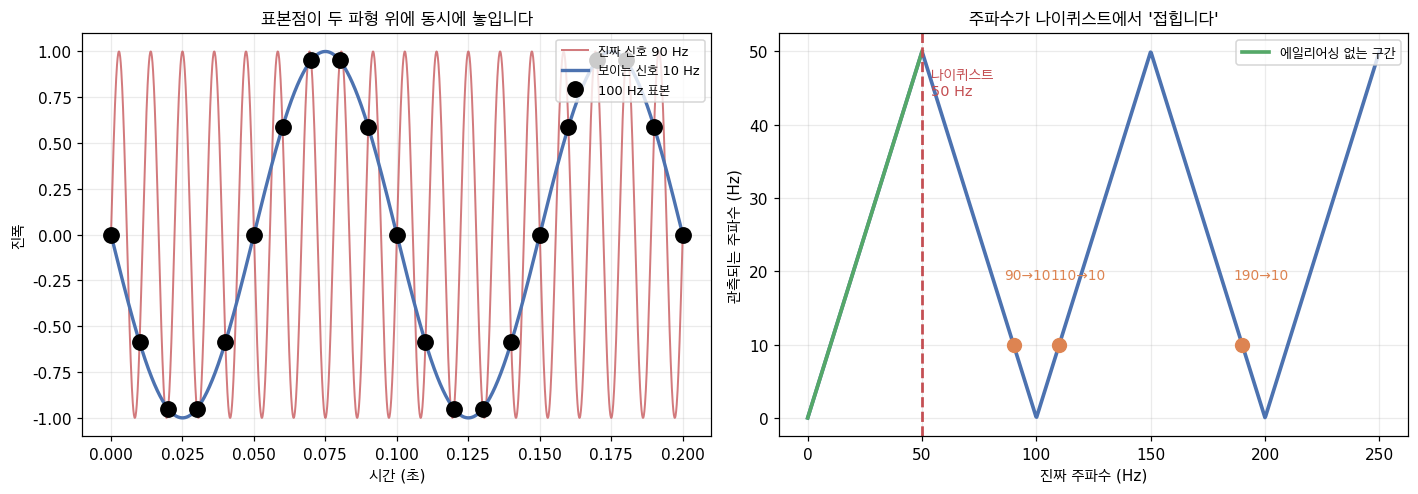

오른쪽 그래프가 톱니처럼 접히는 모양이라 'folding frequency'라고도 부릅니다.
50 Hz를 넘는 순간 주파수가 되접혀서, 서로 다른 주파수들이 같은 값으로 관측됩니다.


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

t_fine = np.linspace(0, 0.2, 2000)
n_samp = np.arange(21)
t_samp = n_samp / fs_sample

ax1.plot(t_fine, np.sin(2*np.pi*90*t_fine), lw=1.3, color="#c44e52", alpha=0.75,
         label="진짜 신호 90 Hz")
ax1.plot(t_fine, -np.sin(2*np.pi*10*t_fine), lw=2.2, color="#4c72b0",
         label="보이는 신호 10 Hz")
ax1.plot(t_samp, np.sin(2*np.pi*90*t_samp), "o", ms=10, color="black", zorder=5,
         label=f"{fs_sample:.0f} Hz 표본")
ax1.set_xlabel("시간 (초)"); ax1.set_ylabel("진폭")
ax1.set_title("표본점이 두 파형 위에 동시에 놓입니다", fontsize=11.5)
ax1.legend(fontsize=8.5, loc="upper right"); ax1.grid(alpha=0.25)

# 진짜 주파수 vs 관측 주파수 (접힘 그래프)
f_true = np.linspace(0, 250, 1000)
f_obs = np.abs(f_true - np.round(f_true / fs_sample) * fs_sample)
ax2.plot(f_true, f_obs, lw=2.4, color="#4c72b0")
ax2.plot([0, fs_sample/2], [0, fs_sample/2], lw=2.4, color="#55a868",
         label="에일리어싱 없는 구간")
ax2.axvline(fs_sample/2, color="#c44e52", ls="--", lw=1.8)
ax2.text(fs_sample/2 + 4, 44, "나이퀴스트\n50 Hz", fontsize=9.5, color="#c44e52")
for f in [90, 110, 190]:
    fo = abs(f - round(f/fs_sample)*fs_sample)
    ax2.plot([f], [fo], "o", ms=9, color="#dd8452", zorder=5)
    ax2.annotate(f"{f}→{fo:.0f}", xy=(f, fo), xytext=(f-4, fo+9), fontsize=9,
                 color="#dd8452")
ax2.set_xlabel("진짜 주파수 (Hz)"); ax2.set_ylabel("관측되는 주파수 (Hz)")
ax2.set_title("주파수가 나이퀴스트에서 '접힙니다'", fontsize=11.5)
ax2.legend(fontsize=9); ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()
print("오른쪽 그래프가 톱니처럼 접히는 모양이라 'folding frequency'라고도 부릅니다.")
print("50 Hz를 넘는 순간 주파수가 되접혀서, 서로 다른 주파수들이 같은 값으로 관측됩니다.")

## 9️⃣ 제로 패딩은 해상도를 올려주지 않습니다

흔한 오해 하나를 짚고 가겠습니다.

> ❌ **"FFT 전에 0을 채우면 주파수 해상도가 좋아진다"**

**아닙니다.** 제로 패딩은 **기존 빈들 사이를 보간**할 뿐입니다.
스펙트럼이 매끄러워 보이긴 하는데, **원래 표본에 없던 주파수 정보를 만들어내지는 못합니다.**

### 🔑 진짜 해상도는 관측 시간에만 의존합니다

$$\Delta f = \frac{1}{T}, \qquad T = \frac{N}{f_s}$$

`Δf`만큼 떨어진 두 주파수를 구분하려면 **최소 `T = 1/Δf` 초**의 데이터가 필요합니다.
0을 아무리 채워도 이 근본적인 한계는 바뀌지 않습니다.

### 📐 그럼 제로 패딩은 왜 하나

두 가지 이유가 있습니다.

1. **FFT를 위해 길이를 2의 거듭제곱으로** 맞추려고 (3절)
2. **선형 합성곱**을 하려고 (5절)

그리고 부수적으로 **봉우리의 위치를 더 정밀하게 읽는 데는 도움**이 됩니다.
"두 봉우리를 나누는 것"과 "한 봉우리의 위치를 정밀하게 읽는 것"은 다른 문제거든요.

아래에서 이 미묘한 차이를 확인해 보겠습니다.

In [17]:
fs = 128
T_short = 0.25                       # 0.25초 -> Δf = 4 Hz
N_short = int(fs * T_short)
t_s = np.arange(N_short) / fs
F1, F2 = 20.0, 21.0                  # 1 Hz 차이 = Δf의 1/4
two_tones = np.sin(2*np.pi*F1*t_s) + np.sin(2*np.pi*F2*t_s)

def dip_depth(P):
    # 두 봉우리 사이에 '진짜 골짜기'가 있어야 분해된 것입니다.
    # 봉우리 개수만 세면 부엽을 봉우리로 착각합니다.
    idx = [i for i in range(1, len(P)-1)
           if P[i] > P[i-1] and P[i] > P[i+1] and P[i] > P.max()*0.2]
    if len(idx) < 2:
        return 0.0
    a, b = idx[0], idx[-1]
    return (min(P[a], P[b]) - P[a:b+1].min()) / P.max()

print(f"신호: {F1:.0f} Hz + {F2:.0f} Hz ({F2-F1:.0f} Hz 차이)")
print(f"관측 시간 {T_short}초, 표본 {N_short}개  ->  Δf = {fs/N_short:.1f} Hz")
print(f"  간격 {F2-F1:.0f} Hz = Δf의 {(F2-F1)/(fs/N_short):.2f}배  ->  이론적으로 구분 불가\n")

print("[방법 A] 제로 패딩으로 빈을 늘려 본다")
print(f"{'':<24}{'빈 개수':>10}{'봉우리 사이 골 깊이':>22}{'분해?':>10}")
print("-" * 68)
for name, padded_N in [("원본 (패딩 없음)", N_short), ("4배 제로 패딩", N_short*4),
                       ("16배 제로 패딩", N_short*16), ("64배 제로 패딩", N_short*64)]:
    P = np.abs(np.fft.rfft(two_tones, n=padded_N)) ** 2
    d = dip_depth(P)
    print(f"{name:<24}{len(P):>10}{d:>22.4f}{'✅' if d > 0.05 else '❌':>10}")

print("\n[방법 B] 관측 시간을 늘린다")
print(f"{'':<24}{'빈 개수':>10}{'봉우리 사이 골 깊이':>22}{'분해?':>10}")
print("-" * 68)
for T_long in [0.25, 0.5, 1.0, 2.0]:
    N_long = int(fs * T_long)
    t_l = np.arange(N_long) / fs
    sig_l = np.sin(2*np.pi*F1*t_l) + np.sin(2*np.pi*F2*t_l)
    P = np.abs(np.fft.rfft(sig_l)) ** 2
    d = dip_depth(P)
    label = f"관측 {T_long}초 (Δf={fs/N_long:.1f}Hz)"
    print(f"{label:<24}{len(P):>10}{d:>22.4f}{'✅' if d > 0.05 else '❌':>10}")

print("\n=> 제로 패딩은 64배(빈 1,025개)까지 늘려도 골짜기가 생기지 않습니다. 봉우리는 계속 하나입니다.")
print(f"   반면 관측을 2초까지 늘려 Δf가 {fs/int(fs*2.0):.1f} Hz — 간격 {F2-F1:.0f} Hz의 절반 — 이 되자")
print("   봉우리가 완전히 갈라졌습니다.")
print("   (1초/Δf=1Hz 에서는 아직 안 갈라집니다. 레일리 기준은 '간격 ≥ Δf'가 아니라")
print("    실제로는 그보다 여유가 좀 더 필요하다는 뜻입니다.)")
print("\n   핵심: 해상도를 결정하는 건 '데이터의 양(관측 시간)'이지 '보간의 촘촘함'이 아닙니다.")
print("\n   ⚠️ 다만 이 '한계'는 칼로 자른 듯한 경계가 아니라 경험칙(레일리 기준)입니다.")
print("      간격이 Δf에 가까운 애매한 구간(예: 0.75·Δf)에서는 제로 패딩이")
print("      숨어 있던 골짜기를 드러내 주기도 합니다. 하지만 간격이 Δf의 절반 아래로")
print("      내려가면 어떤 패딩으로도 불가능합니다 — 정보 자체가 없으니까요.")

신호: 20 Hz + 21 Hz (1 Hz 차이)
관측 시간 0.25초, 표본 32개  ->  Δf = 4.0 Hz
  간격 1 Hz = Δf의 0.25배  ->  이론적으로 구분 불가

[방법 A] 제로 패딩으로 빈을 늘려 본다
                              빈 개수           봉우리 사이 골 깊이       분해?
--------------------------------------------------------------------
원본 (패딩 없음)                      17                0.0000         ❌
4배 제로 패딩                        65                0.0000         ❌
16배 제로 패딩                      257                0.0000         ❌
64배 제로 패딩                     1025                0.0000         ❌

[방법 B] 관측 시간을 늘린다
                              빈 개수           봉우리 사이 골 깊이       분해?
--------------------------------------------------------------------
관측 0.25초 (Δf=4.0Hz)             17                0.0000         ❌
관측 0.5초 (Δf=2.0Hz)              33                0.0000         ❌
관측 1.0초 (Δf=1.0Hz)              65                0.0000         ❌
관측 2.0초 (Δf=0.5Hz)             129                1.0000         ✅

=> 제로 패딩은 64배(빈 1,025개)까지 늘려도 골짜기가 생기지 않습니다

### 🖼️ 그림 6 — 제로 패딩 vs 더 오래 관측하기

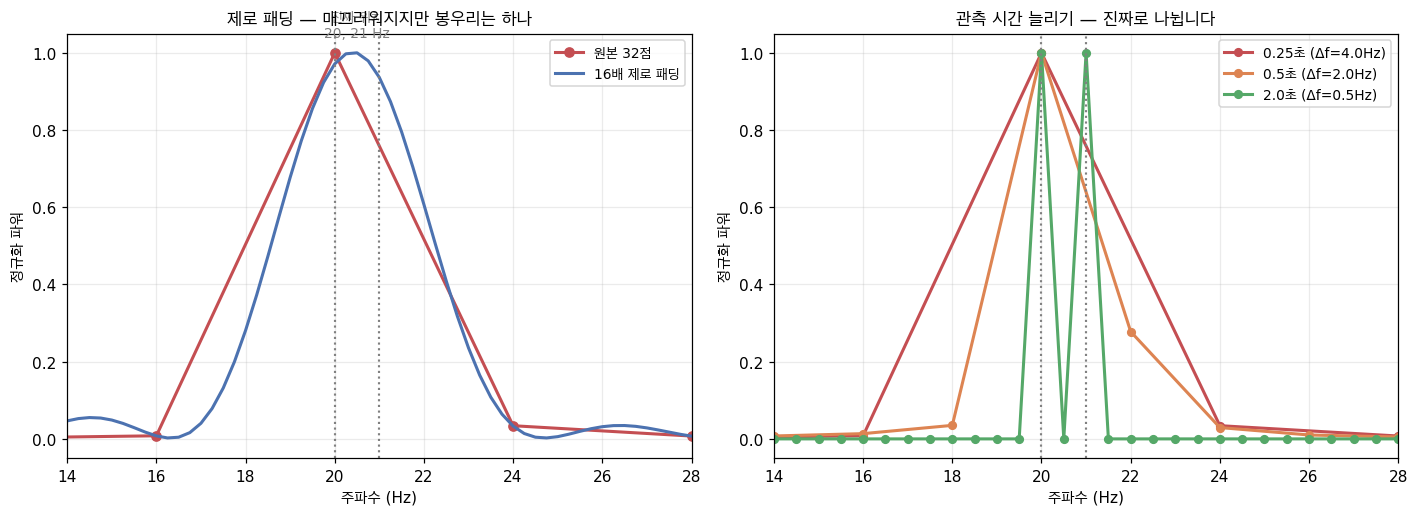

왼쪽: 파란 선(패딩)은 점이 촘촘해졌을 뿐 봉우리는 여전히 하나입니다.
오른쪽: 관측 시간이 늘어나면서 봉우리가 실제로 둘로 갈라집니다.

💡 실무 교훈: '스펙트럼이 뭉개져 보인다'면 패딩이 아니라 데이터를 더 모아야 합니다.


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

for name, padN, c, ls in [("원본 32점", N_short, "#c44e52", "-"),
                          ("16배 제로 패딩", N_short*16, "#4c72b0", "-")]:
    P = np.abs(np.fft.rfft(two_tones, n=padN)) ** 2
    fr = np.fft.rfftfreq(padN, d=1/fs)
    P = P / P.max()
    ax1.plot(fr, P, lw=2, color=c, ls=ls, marker="o" if padN == N_short else None,
             ms=6, label=name)
for f in [F1, F2]:
    ax1.axvline(f, color="gray", ls=":", lw=1.4)
ax1.text(20.5, 1.04, f"진짜 위치\n{F1:.0f}, {F2:.0f} Hz", fontsize=9, ha="center", color="gray")
ax1.set_xlim(14, 28); ax1.set_xlabel("주파수 (Hz)"); ax1.set_ylabel("정규화 파워")
ax1.set_title("제로 패딩 — 매끄러워지지만 봉우리는 하나", fontsize=11.5)
ax1.legend(fontsize=9); ax1.grid(alpha=0.25)

for T_long, c in [(0.25, "#c44e52"), (0.5, "#dd8452"), (2.0, "#55a868")]:
    N_long = int(fs * T_long)
    t_l = np.arange(N_long) / fs
    sig_l = np.sin(2*np.pi*F1*t_l) + np.sin(2*np.pi*F2*t_l)
    P = np.abs(np.fft.rfft(sig_l)) ** 2
    fr = np.fft.rfftfreq(N_long, d=1/fs)
    ax2.plot(fr, P/P.max(), lw=2, marker="o", ms=5, color=c,
             label=f"{T_long}초 (Δf={fs/N_long:.1f}Hz)")
for f in [F1, F2]:
    ax2.axvline(f, color="gray", ls=":", lw=1.4)
ax2.set_xlim(14, 28); ax2.set_xlabel("주파수 (Hz)"); ax2.set_ylabel("정규화 파워")
ax2.set_title("관측 시간 늘리기 — 진짜로 나뉩니다", fontsize=11.5)
ax2.legend(fontsize=9); ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()
print("왼쪽: 파란 선(패딩)은 점이 촘촘해졌을 뿐 봉우리는 여전히 하나입니다.")
print("오른쪽: 관측 시간이 늘어나면서 봉우리가 실제로 둘로 갈라집니다.")
print("\n💡 실무 교훈: '스펙트럼이 뭉개져 보인다'면 패딩이 아니라 데이터를 더 모아야 합니다.")

## 🔟 STFT와 스펙트로그램 — 음성 ML의 입력

FFT 한 번은 **신호 전체의 주파수 내용**을 알려줍니다.
그런데 **그 주파수들이 언제 나타났는지**는 알려주지 않습니다.

**처프**(주파수가 점점 올라가는 신호)와 **화음**(모든 주파수가 동시에)이
**같은 크기 스펙트럼을 가질 수 있습니다.** 0절에서 본 그 두 신호가 그 예였죠.

### 📐 STFT — 짧게 잘라서 여러 번 변환하기

**단시간 푸리에 변환(STFT)** 은 신호를 **겹치는 창으로 잘라 각각 FFT**를 합니다.

```
1. 창 크기를 정한다 (예: 1024 표본)
2. 이동 간격을 정한다 (예: 256 표본 = 75% 겹침)
3. 각 창 위치마다:
   a. 그 구간을 잘라낸다
   b. Hann/Hamming 윈도우를 적용한다   ← 6절
   c. FFT를 계산한다
   d. 크기 스펙트럼을 한 열로 저장한다
```

결과가 **스펙트로그램** — 가로축이 시간, 세로축이 주파수인 2D 표현입니다.

### ⚖️ 여기에도 트레이드오프가 있습니다

- **창이 길면** → 주파수 해상도가 좋아지지만 **시간 해상도가 나빠집니다**
- **창이 짧으면** → 시간 해상도가 좋아지지만 **주파수 해상도가 나빠집니다**

동시에 둘 다 좋게 할 수 없습니다. **불확정성 원리**의 신호처리 버전이에요.

### 🏭 음성 ML의 표준 입력

스펙트로그램은 오디오 ML 모델의 **표준 입력 표현**입니다.
음성인식 모델(**Whisper**, DeepSpeech)은 **멜 스펙트로그램**을 씁니다 —
주파수를 **멜 척도**로 매핑한 것으로, 사람의 음높이 지각에 더 잘 맞습니다.

In [19]:
def stft(signal, win_size, hop, window_fn=hann):
    w = window_fn(win_size)
    cols = []
    for start in range(0, len(signal) - win_size + 1, hop):
        seg = signal[start:start + win_size] * w
        cols.append(np.abs(np.fft.rfft(seg)))
    return np.array(cols).T          # (주파수, 시간)

fs = 512
dur = 2.0
t = np.arange(int(fs*dur)) / fs

# 처프: 주파수가 20 Hz -> 180 Hz 로 선형 증가
f0, f1 = 20.0, 180.0
chirp_sig = np.sin(2*np.pi*(f0*t + (f1-f0)/(2*dur)*t**2))
# 화음: 20, 100, 180 Hz 동시에
chord_sig = (np.sin(2*np.pi*20*t) + np.sin(2*np.pi*100*t) + np.sin(2*np.pi*180*t)) / 3

print("처프 vs 화음 — 전체 FFT로는 구분이 어렵습니다\n")
for name, s in [("처프", chirp_sig), ("화음", chord_sig)]:
    P = np.abs(np.fft.rfft(s))
    fr = np.fft.rfftfreq(len(s), d=1/fs)
    band = (fr >= 15) & (fr <= 185)
    print(f"  {name}: 15~185 Hz 대역에 전체 에너지의 "
          f"{P[band].sum()/P.sum()*100:.1f}%가 있습니다")

print("\n=> 둘 다 같은 대역에 에너지가 있습니다. '언제'를 모르니 구분이 안 됩니다.")
print("   STFT를 쓰면 시간축이 생겨서 확실히 갈립니다 (아래 그림).\n")

for win in [64, 256]:
    S = stft(chirp_sig, win, win // 4)
    print(f"  창 크기 {win:>4}: 스펙트로그램 shape {S.shape}  "
          f"(주파수 해상도 {fs/win:.1f} Hz, 시간 해상도 {win/fs*1000:.0f} ms)")
print("\n  창이 커지면 주파수는 정밀해지고 시간은 뭉개집니다. 그 반대도 마찬가지고요.")

처프 vs 화음 — 전체 FFT로는 구분이 어렵습니다

  처프: 15~185 Hz 대역에 전체 에너지의 96.0%가 있습니다
  화음: 15~185 Hz 대역에 전체 에너지의 100.0%가 있습니다

=> 둘 다 같은 대역에 에너지가 있습니다. '언제'를 모르니 구분이 안 됩니다.
   STFT를 쓰면 시간축이 생겨서 확실히 갈립니다 (아래 그림).

  창 크기   64: 스펙트로그램 shape (33, 61)  (주파수 해상도 8.0 Hz, 시간 해상도 125 ms)
  창 크기  256: 스펙트로그램 shape (129, 13)  (주파수 해상도 2.0 Hz, 시간 해상도 500 ms)

  창이 커지면 주파수는 정밀해지고 시간은 뭉개집니다. 그 반대도 마찬가지고요.


### 🖼️ 그림 7 — 스펙트로그램: 시간과 주파수를 동시에

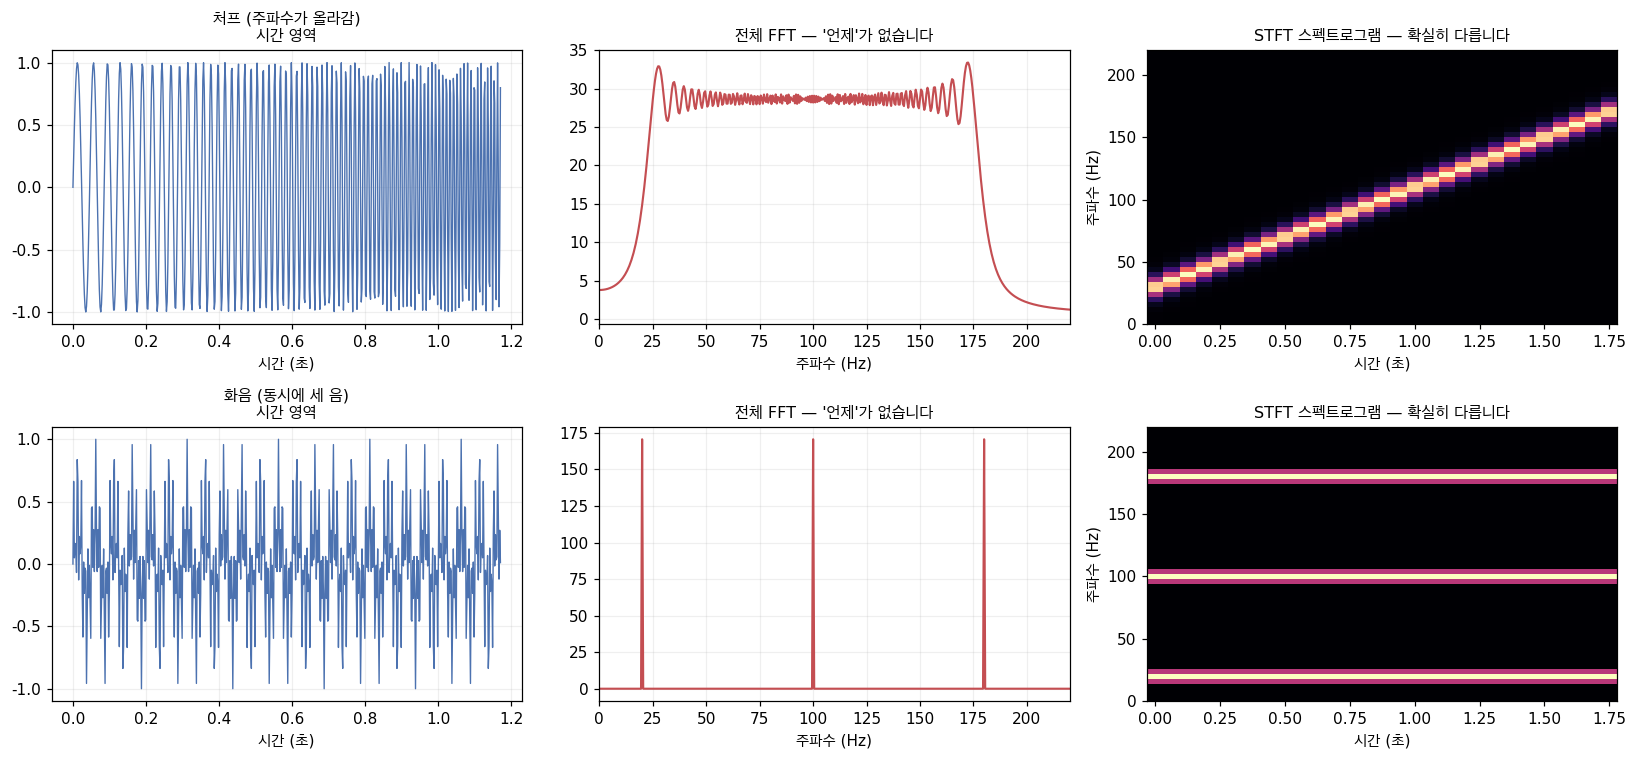

오른쪽 열이 핵심입니다.
  처프: 밝은 선이 '대각선으로 올라갑니다' = 주파수가 시간에 따라 증가
  화음: 밝은 선이 '수평으로 세 줄' = 세 주파수가 계속 함께 존재

가운데 열(전체 FFT)만 봐서는 이 차이를 알 수 없었습니다.
Whisper 같은 음성 모델이 스펙트로그램을 입력으로 받는 이유입니다.


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for row, (name, s) in enumerate([("처프 (주파수가 올라감)", chirp_sig),
                                 ("화음 (동시에 세 음)", chord_sig)]):
    axes[row][0].plot(t[:600], s[:600], lw=0.9, color="#4c72b0")
    axes[row][0].set_title(f"{name}\n시간 영역", fontsize=10.5)
    axes[row][0].set_xlabel("시간 (초)")
    axes[row][0].grid(alpha=0.2)

    P = np.abs(np.fft.rfft(s))
    fr = np.fft.rfftfreq(len(s), d=1/fs)
    axes[row][1].plot(fr, P, lw=1.4, color="#c44e52")
    axes[row][1].set_xlim(0, 220)
    axes[row][1].set_title("전체 FFT — '언제'가 없습니다", fontsize=10.5)
    axes[row][1].set_xlabel("주파수 (Hz)")
    axes[row][1].grid(alpha=0.2)

    win, hop = 128, 32
    S = stft(s, win, hop)
    freqs_s = np.fft.rfftfreq(win, d=1/fs)
    times_s = np.arange(S.shape[1]) * hop / fs
    im = axes[row][2].pcolormesh(times_s, freqs_s, S, shading="auto", cmap="magma")
    axes[row][2].set_ylim(0, 220)
    axes[row][2].set_title("STFT 스펙트로그램 — 확실히 다릅니다", fontsize=10.5)
    axes[row][2].set_xlabel("시간 (초)"); axes[row][2].set_ylabel("주파수 (Hz)")

plt.tight_layout()
plt.show()

print("오른쪽 열이 핵심입니다.")
print("  처프: 밝은 선이 '대각선으로 올라갑니다' = 주파수가 시간에 따라 증가")
print("  화음: 밝은 선이 '수평으로 세 줄' = 세 주파수가 계속 함께 존재")
print("\n가운데 열(전체 FFT)만 봐서는 이 차이를 알 수 없었습니다.")
print("Whisper 같은 음성 모델이 스펙트로그램을 입력으로 받는 이유입니다.")

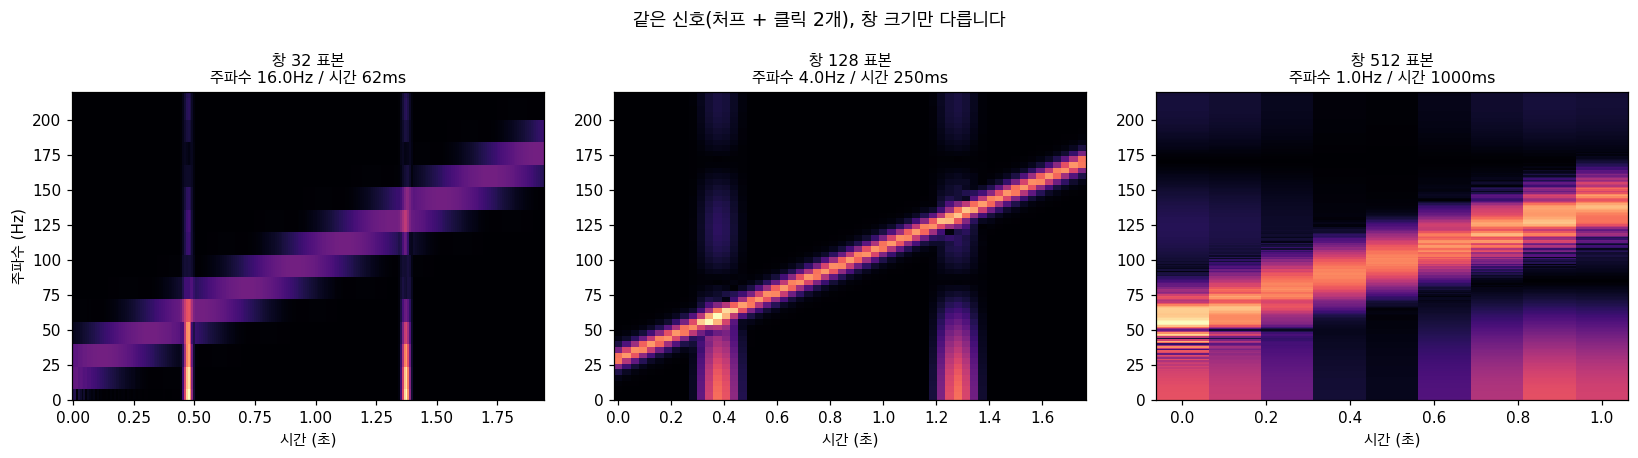

왼쪽(창 32): 클릭 두 개의 '시점'은 선명한데 처프 선이 두껍고 흐릿합니다.
오른쪽(창 512): 처프 선은 가늘고 선명한데 클릭이 시간축으로 번졌습니다.

=> 시간과 주파수를 동시에 정밀하게 볼 수는 없습니다.
   창 크기는 '무엇을 보고 싶은가'에 따라 고르는 하이퍼파라미터입니다.


In [21]:
# 시간-주파수 해상도 트레이드오프를 직접 보여줍니다
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# 처프 + 짧은 클릭 두 개를 섞은 신호
mixed = chirp_sig.copy()
for click_t in [0.5, 1.4]:
    idx = int(click_t * fs)
    mixed[idx:idx+6] += 4.0

for ax, win in zip(axes, [32, 128, 512]):
    S = stft(mixed, win, max(win // 8, 4))
    freqs_s = np.fft.rfftfreq(win, d=1/fs)
    times_s = np.arange(S.shape[1]) * max(win // 8, 4) / fs
    ax.pcolormesh(times_s, freqs_s, S, shading="auto", cmap="magma")
    ax.set_ylim(0, 220)
    ax.set_title(f"창 {win} 표본\n주파수 {fs/win:.1f}Hz / 시간 {win/fs*1000:.0f}ms",
                 fontsize=10.5)
    ax.set_xlabel("시간 (초)")
axes[0].set_ylabel("주파수 (Hz)")
plt.suptitle("같은 신호(처프 + 클릭 2개), 창 크기만 다릅니다", fontsize=12.5)
plt.tight_layout()
plt.show()

print("왼쪽(창 32): 클릭 두 개의 '시점'은 선명한데 처프 선이 두껍고 흐릿합니다.")
print("오른쪽(창 512): 처프 선은 가늘고 선명한데 클릭이 시간축으로 번졌습니다.")
print("\n=> 시간과 주파수를 동시에 정밀하게 볼 수는 없습니다.")
print("   창 크기는 '무엇을 보고 싶은가'에 따라 고르는 하이퍼파라미터입니다.")

## 1️⃣1️⃣ 🏭 트랜스포머 위치 인코딩 · CNN · FNet

### 📐 위치 인코딩 — 왜 하필 그 주파수들인가

원조 트랜스포머의 사인 위치 인코딩입니다.

$$PE(pos, 2i) = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \qquad
PE(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

차원 쌍마다 **다른 주파수로 진동**하고, 주파수는 **기하급수적으로** 배치됩니다
(차원 0,1은 높게 → 마지막 차원은 낮게).

이러면 각 위치가 **모든 주파수 대역에 걸친 고유한 패턴**을 갖습니다.
**푸리에 계수가 신호를 유일하게 특정하는 것과 같은 원리**예요.

이 설계가 주는 성질 세 가지:

1. **유일성** — 두 위치가 같은 인코딩을 갖지 않습니다
2. **유계성** — `sin`, `cos`은 항상 `[−1, 1]`입니다
3. **상대 위치** — `pos+k`의 인코딩을 `pos`의 인코딩의 **선형 함수**로 쓸 수 있습니다.
   그래서 모델이 상대 위치에 주목하도록 학습할 수 있습니다

### 📐 CNN — 합성곱 층은 곧 주파수 필터

합성곱 층은 학습된 커널을 입력 위로 미끄러뜨립니다. 그게 합성곱이죠.
5절의 합성곱 정리에 따르면 이건 **주파수 영역에서 곱하기**와 동등합니다.

즉 **각 커널은 하나의 주파수 필터**입니다.
- 저역 통과 커널 → 흐림(블러)
- 고역 통과 커널 → 경계 검출

표준 CNN 구현은 3×3처럼 작은 커널에는 **직접 합성곱**을 씁니다(그게 더 빠르니까요).
하지만 **큰 커널이나 전역 합성곱**에서는 FFT 기반이 훨씬 빠릅니다.

### 📐 FNet — 어텐션을 아예 FFT로 바꾼다면

**FNet**(2021)은 셀프 어텐션을 **FFT로 통째로 대체**합니다.
학습 파라미터가 없는 고정된 변환인데도 BERT 성능의 상당 부분을 유지하면서,
복잡도를 **O(N²) → O(N log N)** 으로 낮췄습니다.

"토큰을 섞는(mixing) 것"이 어텐션의 핵심 역할 중 하나인데,
**푸리에 변환도 모든 위치를 섞는 연산**이라는 통찰입니다.

In [22]:
# 연습 5 — 위치 인코딩의 내적이 상대 거리에만 의존하는가
def sinusoidal_pe(max_pos, d_model, base=10000.0):
    pos = np.arange(max_pos)[:, None]
    i = np.arange(0, d_model, 2)
    omega = 1.0 / (base ** (i / d_model))
    pe = np.zeros((max_pos, d_model))
    pe[:, 0::2] = np.sin(pos * omega)
    pe[:, 1::2] = np.cos(pos * omega)
    return pe

PE = sinusoidal_pe(512, 128)
print(f"위치 인코딩 {PE.shape}  (위치 512 × 차원 128)\n")

print("[내적이 절대 위치와 무관한가]")
print(f"{'상대 거리 k':>12}{'표본 수':>10}{'내적 평균':>14}{'내적 표준편차':>16}")
print("-" * 54)
for k in [0, 1, 2, 5, 10, 50, 200]:
    vals = [PE[p] @ PE[p+k] for p in range(0, 512-k, 7)]
    v = np.array(vals)
    print(f"{k:>12}{len(v):>10}{v.mean():>14.6f}{v.std():>16.2e}")

print("\n=> 같은 상대 거리 안에서 표준편차가 0에 가깝습니다.")
print("   절대 위치가 0이든 300이든, 거리만 같으면 내적이 같습니다.")

print("\n[거리가 멀어지면 내적은 어떻게 되나]")
ks = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
for k in ks:
    vals = np.array([PE[p] @ PE[p+k] for p in range(0, 512-k, 7)])
    bar = "█" * max(int(vals.mean() / 2), 0)
    print(f"  k={k:>4}: 내적 {vals.mean():>8.3f}  {bar}")
print("\n  => 거리가 멀어지면 내적이 줄어듭니다 (일종의 '거리 감쇠').")
print("     단조롭게 줄지는 않고 진동하는데, 여러 주파수가 겹쳐 있기 때문입니다.")

위치 인코딩 (512, 128)  (위치 512 × 차원 128)

[내적이 절대 위치와 무관한가]
     상대 거리 k      표본 수         내적 평균         내적 표준편차
------------------------------------------------------
           0        74     64.000000        8.14e-15
           1        73     62.093684        2.65e-14
           2        73     57.381861        3.48e-14
           5        73     47.185012        2.75e-14
          10        72     42.820023        2.16e-14
          50        66     34.955011        2.35e-14
         200        45     19.564012        2.68e-14

=> 같은 상대 거리 안에서 표준편차가 0에 가깝습니다.
   절대 위치가 0이든 300이든, 거리만 같으면 내적이 같습니다.

[거리가 멀어지면 내적은 어떻게 되나]
  k=   0: 내적   64.000  ████████████████████████████████
  k=   1: 내적   62.094  ███████████████████████████████
  k=   2: 내적   57.382  ████████████████████████████
  k=   4: 내적   48.586  ████████████████████████
  k=   8: 내적   45.721  ██████████████████████
  k=  16: 내적   39.702  ███████████████████
  k=  32: 내적   35.678  █████████████████
  k=  64: 내적   30.520  ██████

### 🖼️ 그림 8 — 위치 인코딩과 CNN 커널을 주파수로 보기

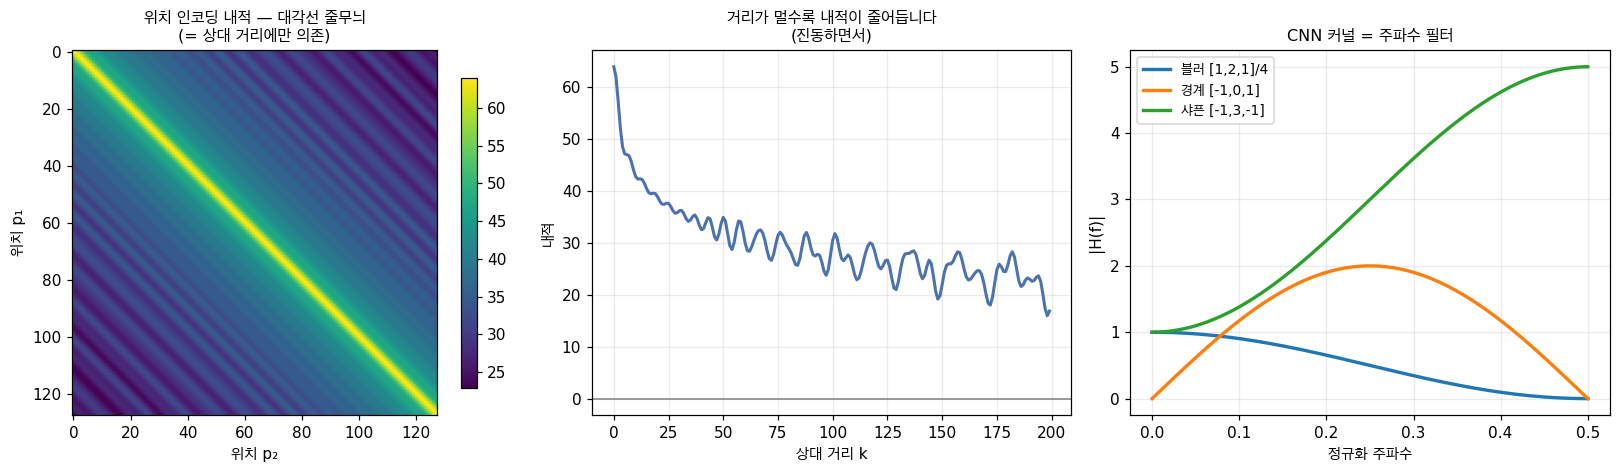

오른쪽 그림이 CNN을 보는 새로운 관점입니다.
  블러 커널: 저주파는 통과(값 1), 고주파는 차단(값 0) → 저역 통과 필터
  경계 커널: 저주파는 차단(0), 고주파는 통과 → 고역 통과 필터

  '블러는 부드럽게, 경계는 날카롭게'가 주파수 응답으로 정확히 설명됩니다.
  CNN이 학습하는 건 결국 '어떤 주파수를 통과시킬 것인가'입니다.


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# (1) PE 내적 행렬
sub = PE[:128]
dots = sub @ sub.T
im = axes[0].imshow(dots, cmap="viridis")
axes[0].set_xlabel("위치 p₂"); axes[0].set_ylabel("위치 p₁")
axes[0].set_title("위치 인코딩 내적 — 대각선 줄무늬\n(= 상대 거리에만 의존)", fontsize=10.5)
plt.colorbar(im, ax=axes[0], shrink=0.85)

# (2) 거리에 따른 내적
ks_fine = np.arange(0, 200)
means = [np.mean([PE[p] @ PE[p+k] for p in range(0, 300, 5)]) for k in ks_fine]
axes[1].plot(ks_fine, means, lw=2, color="#4c72b0")
axes[1].axhline(0, color="gray", lw=1)
axes[1].set_xlabel("상대 거리 k"); axes[1].set_ylabel("내적")
axes[1].set_title("거리가 멀수록 내적이 줄어듭니다\n(진동하면서)", fontsize=10.5)
axes[1].grid(alpha=0.25)

# (3) CNN 커널의 주파수 응답
kernels = {
    "블러 [1,2,1]/4": np.array([1., 2., 1.]) / 4,
    "경계 [-1,0,1]": np.array([-1., 0., 1.]),
    "샤픈 [-1,3,-1]": np.array([-1., 3., -1.]),
}
for name, ker in kernels.items():
    H = np.abs(np.fft.rfft(ker, n=256))
    fr = np.fft.rfftfreq(256)
    axes[2].plot(fr, H, lw=2.2, label=name)
axes[2].set_xlabel("정규화 주파수"); axes[2].set_ylabel("|H(f)|")
axes[2].set_title("CNN 커널 = 주파수 필터", fontsize=10.5)
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("오른쪽 그림이 CNN을 보는 새로운 관점입니다.")
print("  블러 커널: 저주파는 통과(값 1), 고주파는 차단(값 0) → 저역 통과 필터")
print("  경계 커널: 저주파는 차단(0), 고주파는 통과 → 고역 통과 필터")
print("\n  '블러는 부드럽게, 경계는 날카롭게'가 주파수 응답으로 정확히 설명됩니다.")
print("  CNN이 학습하는 건 결국 '어떤 주파수를 통과시킬 것인가'입니다.")

## 1️⃣2️⃣ 📝 연습문제 (풀이 포함)

1. **순음 찾기** — 미지의 주파수를 가진 사인파를 128Hz로 1초 표본화해 DFT로 주파수를 찾기. 노이즈를 더하면 스펙트럼이 어떻게 변하나?
2. **FFT vs DFT 검증** — 길이 64에서 두 구현이 일치하는지, 그리고 길이별 속도비를 측정. *(→ 3절에서 완료)*
3. **합성곱 정리** — 원형 합성곱과 선형 합성곱을 직접·FFT 두 방법으로 계산해 비교. *(→ 5절에서 완료)*
4. **윈도우 효과** — 10Hz와 12Hz를 섞은 신호에서 윈도우별로 두 봉우리 구분 능력을 비교.
5. **위치 인코딩 분석** — `d_model=128`, `max_pos=512`에서 내적이 `|p₁−p₂|`에만 의존함을 보이기. *(→ 11절에서 완료)*

In [24]:
print("=" * 74)
print("연습 1 — 순음 찾기 (노이즈 있을 때와 없을 때)")
print("=" * 74)
fs, N = 128, 128
t = np.arange(N) / fs
rng = np.random.default_rng(42)
secret_f = 37.0                                  # '미지의' 주파수
clean = np.sin(2*np.pi*secret_f*t)

print(f"(정답은 {secret_f:.0f} Hz 이지만 모른다고 치고 스펙트럼으로 찾아봅니다)\n")
print("한 번만 돌리면 운에 좌우되므로, 노이즈 수준마다 200회 반복해 성공률을 봅니다.\n")
print(f"{'노이즈 σ':>10}{'봉우리 대 배경(dB)':>20}{'200회 중 정답':>16}{'성공률':>10}")
print("-" * 58)
for noise_sd in [0.0, 0.5, 2.0, 5.0, 10.0]:
    hits, snrs = 0, []
    for seed in range(200):
        r = np.random.default_rng(seed)
        obs = clean + noise_sd * r.normal(size=N)
        P = np.abs(np.fft.rfft(obs)) ** 2
        fr = np.fft.rfftfreq(N, d=1/fs)
        hits += abs(fr[int(np.argmax(P))] - secret_f) < 1e-9
        bg = np.median(P)
        if bg > 0:
            snrs.append(10 * math.log10(P.max() / bg))
    snr_txt = f"{np.mean(snrs):.1f}" if snrs else "inf"
    print(f"{noise_sd:>10.1f}{snr_txt:>20}{hits:>16}{hits/2:>9.0f}%")

print("\n=> σ=2 까지는 90% 성공합니다. 시간 영역에서는 이미 신호가 안 보이는 수준인데도요.")
print("   노이즈는 모든 주파수에 고르게 흩어지지만(백색), 신호는 한 빈에 모이기 때문입니다.")
print("   ⚠️ 하지만 무한정 버티지는 못합니다. σ=5 부터는 성공률이 급락합니다.")
print("      '푸리에는 노이즈에 강하다'는 맞지만 '노이즈를 이긴다'는 아닙니다.")

연습 1 — 순음 찾기 (노이즈 있을 때와 없을 때)
(정답은 37 Hz 이지만 모른다고 치고 스펙트럼으로 찾아봅니다)

한 번만 돌리면 운에 좌우되므로, 노이즈 수준마다 200회 반복해 성공률을 봅니다.

     노이즈 σ        봉우리 대 배경(dB)       200회 중 정답       성공률
----------------------------------------------------------
       0.0               307.4             200      100%
       0.5                22.8             200      100%
       2.0                11.2             179       90%
       5.0                 8.5              33       16%
      10.0                 8.3               7        4%

=> σ=2 까지는 90% 성공합니다. 시간 영역에서는 이미 신호가 안 보이는 수준인데도요.
   노이즈는 모든 주파수에 고르게 흩어지지만(백색), 신호는 한 빈에 모이기 때문입니다.
   ⚠️ 하지만 무한정 버티지는 못합니다. σ=5 부터는 성공률이 급락합니다.
      '푸리에는 노이즈에 강하다'는 맞지만 '노이즈를 이긴다'는 아닙니다.


### 🖼️ 그림 9 — 노이즈 속에서 신호 찾기

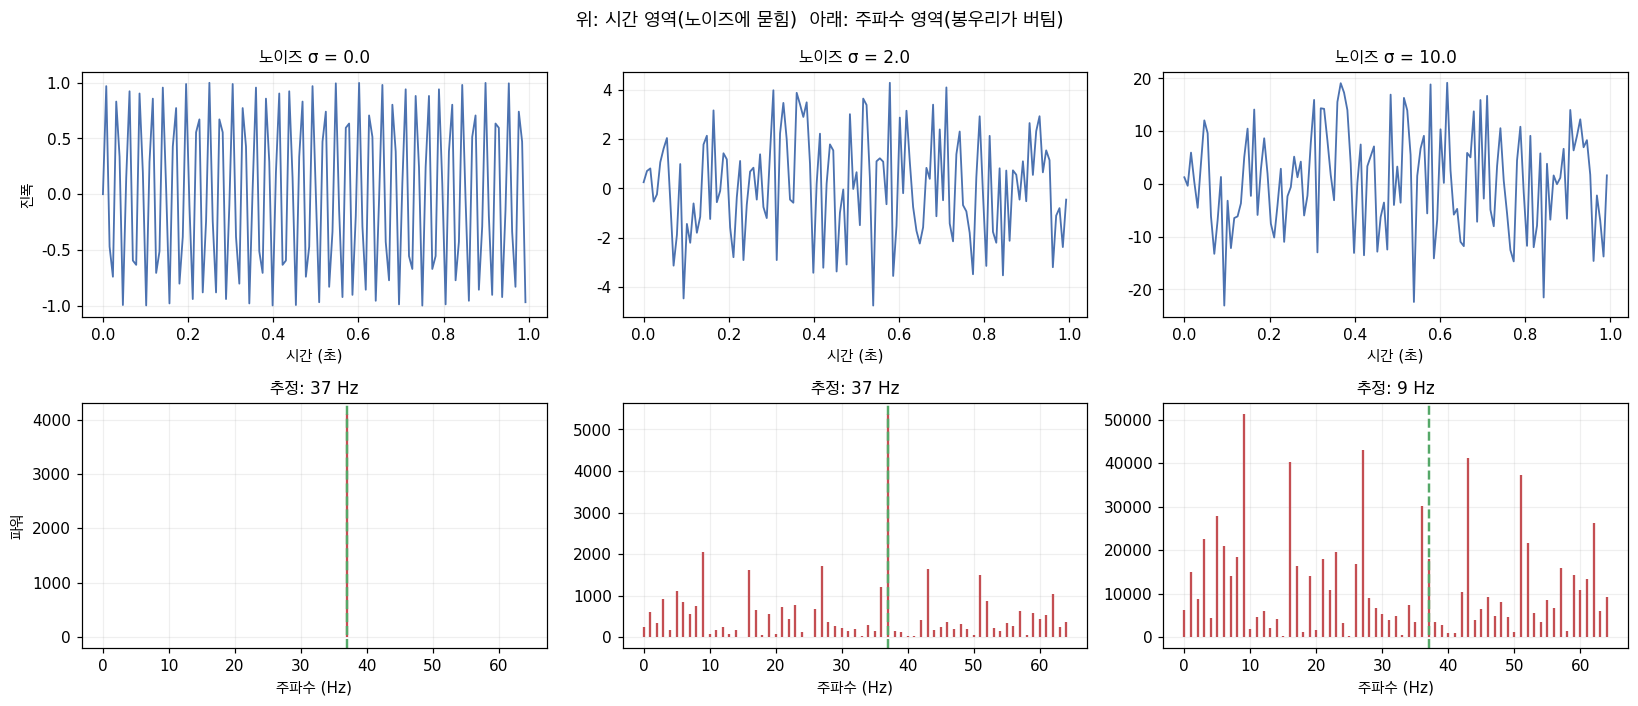

가운데 열(σ=2)을 보세요. 위에서는 사인파를 알아보기 어려운데
아래에서는 37 Hz 봉우리가 뚜렷합니다. 이게 주파수 영역의 힘입니다.
오른쪽 열(σ=10)에서는 그 봉우리마저 배경에 묻히기 시작합니다.


In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6.5))
for col, noise_sd in enumerate([0.0, 2.0, 10.0]):
    obs = clean + noise_sd * np.random.default_rng(0).normal(size=N)
    axes[0][col].plot(t, obs, lw=1.2, color="#4c72b0")
    axes[0][col].set_title(f"노이즈 σ = {noise_sd}", fontsize=11)
    axes[0][col].set_xlabel("시간 (초)")
    axes[0][col].grid(alpha=0.2)

    P = np.abs(np.fft.rfft(obs)) ** 2
    fr = np.fft.rfftfreq(N, d=1/fs)
    axes[1][col].stem(fr, P, basefmt=" ", linefmt="#c44e52", markerfmt=" ")
    axes[1][col].axvline(secret_f, color="#55a868", ls="--", lw=1.6)
    axes[1][col].set_xlabel("주파수 (Hz)")
    axes[1][col].set_title(f"추정: {fr[int(np.argmax(P))]:.0f} Hz", fontsize=11)
    axes[1][col].grid(alpha=0.2)
axes[0][0].set_ylabel("진폭"); axes[1][0].set_ylabel("파워")
plt.suptitle("위: 시간 영역(노이즈에 묻힘)  아래: 주파수 영역(봉우리가 버팀)", fontsize=12.5)
plt.tight_layout()
plt.show()
print("가운데 열(σ=2)을 보세요. 위에서는 사인파를 알아보기 어려운데")
print("아래에서는 37 Hz 봉우리가 뚜렷합니다. 이게 주파수 영역의 힘입니다.")
print("오른쪽 열(σ=10)에서는 그 봉우리마저 배경에 묻히기 시작합니다.")

In [26]:
print("=" * 74)
print("연습 4 — 윈도우별 두 봉우리 구분 능력")
print("=" * 74)
fs, N = 128, 128
t = np.arange(N) / fs
two = np.sin(2*np.pi*10*t) + np.sin(2*np.pi*12*t)
print(f"신호: 10 Hz + 12 Hz (2 Hz 차이),  Δf = {fs/N:.1f} Hz\n")

fr = np.fft.rfftfreq(N, d=1/fs)
print(f"{'윈도우':<16}{'10Hz 파워':>14}{'11Hz 골짜기':>14}{'12Hz 파워':>14}{'골 깊이':>12}{'구분':>8}")
print("-" * 80)
for name, w in [("사각형(없음)", np.ones(N)), ("Hann", hann(N)),
                ("Hamming", hamming(N)), ("Blackman", blackman(N))]:
    P = np.abs(np.fft.rfft(two * w)) ** 2
    P = P / P.max()
    i10, i11, i12 = 10, 11, 12
    depth = min(P[i10], P[i12]) - P[i11]         # 봉우리 대비 골짜기 깊이
    ok = "✅" if depth > 0 else "❌"
    print(f"{name:<16}{P[i10]:>14.4f}{P[i11]:>14.4f}{P[i12]:>14.4f}{depth:>12.4f}{ok:>8}")

print("\n💡 읽는 법: '골 깊이'가 양수여야 두 봉우리가 실제로 나뉜 것입니다.")
print("   사각형 윈도우가 두 봉우리를 가장 잘 나눕니다 — 주엽이 가장 좁으니까요.")
print("   Blackman은 골짜기가 메워집니다 — 부엽을 낮춘 대가로 주엽이 넓어졌기 때문입니다.")
print("\n   ⚠️ 그래서 '윈도우는 항상 좋다'가 아닙니다.")
print("      누설이 문제면 윈도우를 쓰고, 가까운 주파수 분해가 목적이면 오히려 방해가 됩니다.")

연습 4 — 윈도우별 두 봉우리 구분 능력
신호: 10 Hz + 12 Hz (2 Hz 차이),  Δf = 1.0 Hz

윈도우                    10Hz 파워      11Hz 골짜기       12Hz 파워        골 깊이      구분
--------------------------------------------------------------------------------
사각형(없음)                 1.0000        0.0000        1.0000      1.0000       ✅
Hann                    0.9827        1.0000        0.9827     -0.0173       ❌
Hamming                 1.0000        0.7373        1.0000      0.2627       ✅
Blackman                0.8392        1.0000        0.8392     -0.1608       ❌

💡 읽는 법: '골 깊이'가 양수여야 두 봉우리가 실제로 나뉜 것입니다.
   사각형 윈도우가 두 봉우리를 가장 잘 나눕니다 — 주엽이 가장 좁으니까요.
   Blackman은 골짜기가 메워집니다 — 부엽을 낮춘 대가로 주엽이 넓어졌기 때문입니다.

   ⚠️ 그래서 '윈도우는 항상 좋다'가 아닙니다.
      누설이 문제면 윈도우를 쓰고, 가까운 주파수 분해가 목적이면 오히려 방해가 됩니다.


## 1️⃣3️⃣ 📚 용어 사전 (Key Terms)

| 용어 | 실제 의미 |
| --- | --- |
| **DFT** | `N`개 시간 표본을 `N`개 주파수 계수로 변환. 각 계수는 그 주파수의 복소 사인파와의 상관 |
| **FFT** | DFT를 **O(N log N)** 에 계산하는 알고리즘. 쿨리-튜키는 짝/홀 인덱스로 재귀 분할 |
| **역 DFT** | 주파수 계수에서 신호를 복원. 지수 부호를 뒤집고 `1/N`을 곱합니다 |
| **주파수 빈** | DFT 출력의 인덱스 `k`. `k·fs/N` Hz에 해당하는 이산 주파수 슬롯 |
| **DC 성분** | `X[0]`. 0 주파수 계수. 신호의 평균에 비례합니다 |
| **나이퀴스트 주파수** | `fs/2`. 표본화율 `fs`로 표현 가능한 최고 주파수. 넘으면 에일리어싱 |
| **파워 스펙트럼** | `\|X[k]\|²`. 주파수별 에너지 분포 |
| **위상 스펙트럼** | `arg(X[k])`. 분석에서는 자주 무시하지만 **복원에는 필수** |
| **스펙트럼 누설** | 비주기 신호를 주기로 취급해 생기는 가짜 주파수 성분. 윈도우로 완화 |
| **윈도우 함수** | Hann·Hamming·Blackman 등. DFT 전에 곱해 누설을 줄입니다. **대가로 해상도 손실** |
| **트위들 인자** | FFT 버터플라이에서 부분 DFT를 합칠 때 쓰는 `e^(−2πik/N)` |
| **합성곱 정리** | 시간 영역의 합성곱 = 주파수 영역의 원소별 곱. **CNN과 신호처리의 기반** |
| **원형 합성곱** | 끝에서 처음으로 되감기는 합성곱. **DFT가 자연스럽게 계산하는 것** |
| **선형 합성곱** | 되감기 없는 보통의 합성곱. 제로 패딩으로 구현합니다 |
| **파스발 정리** | 변환 전후로 에너지가 보존됩니다. `Σ\|x\|² = (1/N)Σ\|X\|²` |
| **에일리어싱** | 나이퀴스트를 넘는 주파수가 낮은 주파수로 둔갑하는 현상. **복구 불가능** |
| **STFT / 스펙트로그램** | 겹치는 창마다 FFT. 시간-주파수 2D 표현. 음성 ML의 표준 입력 |

---

## 🎯 한 문장 정리

> **푸리에 변환은 "언제 무슨 일이 일어났나"를 "어떤 주파수가 얼마나 있나"로 바꾸는
> 기저 변환입니다. 정보는 하나도 잃지 않고, 다만 보이는 것이 달라집니다.**

| 배운 것 | 실무에서 |
| --- | --- |
| DFT는 가역 기저 변환 (2절) | 정보 손실 없음. 위상까지 있어야 복원됩니다 |
| FFT는 O(N log N) (3절) | 이게 없으면 주파수 분석이 불가능합니다 |
| **합성곱 = 주파수 곱셈 (5절)** | **CNN 커널 = 주파수 필터** |
| 윈도우는 트레이드오프 (6절) | 누설 억제 ↔ 해상도, 둘 중 하나 |
| 에일리어싱 (8절) | 다운샘플링 전에 저역 통과 필터를 거세요 |
| 해상도 = 1/관측시간 (9절) | 제로 패딩으로는 해결 안 됩니다 |
| STFT (10절) | 시간·주파수 동시 정밀은 불가능. 창 크기가 선택 |

---

## 📖 더 읽을거리

- [Cooley & Tukey (1965): FFT 원논문](https://www.ams.org/journals/mcom/1965-19-090/S0025-5718-1965-0178586-1/) — 컴퓨팅의 판도를 바꾼 논문
- [3Blue1Brown: 푸리에 변환이란 무엇인가](https://www.youtube.com/watch?v=spUNpyF58BY) — 가장 좋은 시각적 입문
- [Lee-Thorp et al.: FNet (2021)](https://arxiv.org/abs/2105.03824) — 셀프 어텐션을 FFT로 대체
- [The Scientist and Engineer's Guide to DSP](http://www.dspguide.com/) — FFT·윈도우·스펙트럼 분석을 깊게 다루는 무료 교재
- [Radford et al.: Whisper (2022)](https://arxiv.org/abs/2212.04356) — 멜 스펙트로그램을 입력으로 쓰는 음성인식